In [ ]:
import os
import pickle

SAVE_PATH = "models/"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"✅ Local save path created: {os.path.abspath(SAVE_PATH)}")

✅ Local save path created: /content/models


In [ ]:
from tensorflow.keras.models import load_model

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pickle
SAVE_PATH = "/content/drive/MyDrive/TimeSeriesModels/each_store"
os.makedirs(SAVE_PATH, exist_ok=True)

print(f"✅ Google Drive mounted and save path created: {SAVE_PATH}")

✅ Google Drive mounted and save path created: /content/drive/MyDrive/TimeSeriesModels/each_store


# 🏪 Rossmann Store-Wise Sales Forecasting — Complete Deep Learning Suite

> **Per-store daily sales forecasting** using SimpleRNN, LSTM, BiLSTM, GRU, Transformer,
> TCN, N-HiTS, and PatchTST.
>
> **Key improvements over baseline:**
> - Richer lag/rolling features (lags 1, 7, 14, 21, 28 + rolling mean/std windows)
> - Cyclical DayOfWeek & Month encoding, monotone Trend feature
> - Larger window size (60 steps ≈ 2 months of history)
> - Huber loss (robust to sales outliers), BatchNorm, L2 regularisation
> - Stacked two-layer architectures for all RNN-family models
> - New models: BiLSTM, TCN, N-HiTS, PatchTST

---

## 📦 SECTION 0 — Imports & Global Setup

In [ ]:
!pip install statsmodels

In [ ]:
!pip install tensorflow

In [ ]:
pip install matplotlib

In [ ]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout,
    BatchNormalization, Bidirectional,
    Conv1D, MaxPooling1D, Flatten,
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D,
    Add, Activation
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

from statsmodels.graphics.tsaplots import plot_acf

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# ── Global hyper-parameters ─────────────────────────────────────────────────
WINDOW_SIZE  = 60     # 2 months of history — captures weekly + monthly patterns
SPLIT_RATIO  = 0.80
BATCH_SIZE   = 32     # smaller batch → better gradient estimates
MAX_EPOCHS   = 150    # early stopping will cut short
PATIENCE_ES  = 20     # EarlyStopping patience
PATIENCE_LR  = 8      # ReduceLROnPlateau patience

print("✅ All imports successful. TF version:", tf.__version__)
print(f"   Window={WINDOW_SIZE} | Split={SPLIT_RATIO} | Batch={BATCH_SIZE} | MaxEpochs={MAX_EPOCHS}")

✅ All imports successful. TF version: 2.21.0
   Window=60 | Split=0.8 | Batch=32 | MaxEpochs=150


In [ ]:
import pickle

## 📥 SECTION 1 — Load Data

In [ ]:
df_train = pd.read_csv(
    'https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/'
    'refs/heads/master/dataset/train.csv',
    low_memory=False
)
df_store = pd.read_csv(
    'https://raw.githubusercontent.com/sarthaksoni25/Rossmann-Store-Sales-Prediction/'
    'refs/heads/master/dataset/store.csv',
    low_memory=False
)
print(f'Train shape: {df_train.shape}  |  Store shape: {df_store.shape}')
display(df_train.head())


Train shape: (1001599, 10)  |  Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id
0,1,5,2015-07-17,4852,519,1,1,0,0,303445
1,2,5,2015-07-17,4518,495,1,1,0,1,959585
2,3,5,2015-07-17,6679,673,1,1,0,1,739744
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001
4,5,5,2015-07-17,4355,513,1,1,0,1,981931


## 🔗 SECTION 2 — Merge Store Metadata

In [ ]:

df = pd.merge(df_train, df_store, on='Store', how='left')
print(f'Merged shape: {df.shape}')
display(df.head())


Merged shape: (1001599, 19)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-17,4852,519,1,1,0,0,303445,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-17,4518,495,1,1,0,1,959585,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-17,6679,673,1,1,0,1,739744,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-17,4355,513,1,1,0,1,981931,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 🧹 SECTION 3 — Filter Closed Days

In [ ]:
df = df[df['Open'] != 0].drop('Open', axis=1)
print(f'Shape after removing closed days: {df.shape}')


Shape after removing closed days: (830972, 18)


## 📅 SECTION 4 — Date Feature Engineering

> **Improvements:** Cyclical sin/cos encoding for both Month and DayOfWeek prevents
> the discontinuity at period boundaries (e.g. Dec→Jan, Sat→Sun).
> A monotone `Trend` column gives the model a linear time signal.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year']       = df['Date'].dt.year
df['Month']      = df['Date'].dt.month
df['Day']        = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['DayOfWeek']  = df['Date'].dt.dayofweek          # 0=Mon … 6=Sun
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

# Cyclical encoding — removes boundary discontinuities
df['Month_sin']      = np.sin(2 * np.pi * df['Month']     / 12)
df['Month_cos']      = np.cos(2 * np.pi * df['Month']     / 12)
df['DayOfWeek_sin']  = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos']  = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

print(f'Shape after date engineering: {df.shape}')
display(df.head())


Shape after date engineering: (830972, 27)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id,StoreType,...,PromoInterval,Year,Month,Day,WeekOfYear,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,4,2015-07-17,4852,519,1,0,0,303445,c,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
1,2,4,2015-07-17,4518,495,1,0,1,959585,a,...,"Jan,Apr,Jul,Oct",2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
2,3,4,2015-07-17,6679,673,1,0,1,739744,a,...,"Jan,Apr,Jul,Oct",2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
3,4,4,2015-07-17,10514,1343,1,0,1,864001,c,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
4,5,4,2015-07-17,4355,513,1,0,1,981931,a,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969


## 🏪 SECTION 5 — Encode Categorical Features

In [ ]:
le = LabelEncoder()
for col in ['StateHoliday', 'StoreType', 'Assortment']:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Store ID kept numeric; already 1-based integers
print(f'Unique stores: {df["Store"].nunique()}')
display(df.head())


Unique stores: 1115


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id,StoreType,...,PromoInterval,Year,Month,Day,WeekOfYear,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos
0,1,4,2015-07-17,4852,519,1,0,0,303445,2,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
1,2,4,2015-07-17,4518,495,1,0,1,959585,0,...,"Jan,Apr,Jul,Oct",2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
2,3,4,2015-07-17,6679,673,1,0,1,739744,0,...,"Jan,Apr,Jul,Oct",2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
3,4,4,2015-07-17,10514,1343,1,0,1,864001,2,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969
4,5,4,2015-07-17,4355,513,1,0,1,981931,0,...,NaN,2015,7,17,29,0,-0.5,-0.866025,-0.433884,-0.900969


## 📏 SECTION 6 — Competition Distance (log-transform)

In [ ]:
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompetitionDistance'] = np.log1p(df['CompetitionDistance'])   # reduce right-skew
print(df['CompetitionDistance'].describe())


count    830972.000000
mean          7.644881
std           1.558382
min           3.044522
25%           6.566672
50%           7.749753
75%           8.836519
max          11.236658
Name: CompetitionDistance, dtype: float64


## 🏆 SECTION 7 — Competition Open Days Feature

In [ ]:
df['CompetitionOpenDate'] = pd.to_datetime(
    df['CompetitionOpenSinceYear'].astype(str) + '-' +
    df['CompetitionOpenSinceMonth'].astype(str) + '-01',
    errors='coerce'
)
df['NoCompetitionInfo']   = df['CompetitionOpenSinceYear'].isna().astype(int)
df['CompetitionOpenDate'] = df['CompetitionOpenDate'].fillna(df['Date'].min())
df['CompetitionOpenDays'] = (df['Date'] - df['CompetitionOpenDate']).dt.days.clip(lower=0)

df.drop(['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
         'CompetitionOpenDate'], axis=1, inplace=True)
print(df['CompetitionOpenDays'].describe())


count    830972.000000
mean        457.456734
std         270.075325
min           0.000000
25%         224.000000
50%         447.000000
75%         696.000000
max         927.000000
Name: CompetitionOpenDays, dtype: float64


## 🎁 SECTION 8 — Promo2 Features

In [ ]:
df['Promo2StartDate'] = pd.to_datetime(
    df['Promo2SinceYear'].astype(str) + '-' + df['Promo2SinceWeek'].astype(str) + '-1',
    format='%Y-%W-%w', errors='coerce'
)
df['NoPromo2']          = df['Promo2SinceYear'].isna().astype(int)
df['Promo2StartDate']   = df['Promo2StartDate'].fillna(df['Date'].min())
df['Promo2RunningDays'] = (df['Date'] - df['Promo2StartDate']).dt.days.clip(lower=0)

def is_promo_month(row):
    if pd.isna(row['PromoInterval']):
        return 0
    return 1 if row['Date'].strftime('%b') in row['PromoInterval'].split(',') else 0

df['IsPromoMonth'] = df.apply(is_promo_month, axis=1)
df.drop(['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
         'Promo2StartDate'], axis=1, inplace=True)
print(df[['Promo2', 'Promo2RunningDays', 'IsPromoMonth', 'NoPromo2']].describe())


              Promo2  Promo2RunningDays   IsPromoMonth       NoPromo2
count  830972.000000      830972.000000  830972.000000  830972.000000
mean        0.498485         457.456734       0.163817       0.501515
std         0.499998         270.075325       0.370109       0.499998
min         0.000000           0.000000       0.000000       0.000000
25%         0.000000         224.000000       0.000000       0.000000
50%         0.000000         447.000000       0.000000       1.000000
75%         1.000000         696.000000       0.000000       1.000000
max         1.000000         927.000000       1.000000       1.000000


## 📊 SECTION 9 — Sort & ACF Analysis

In [ ]:
df = df.sort_values(by=['Store', 'Date']).reset_index(drop=True)
print(f'Sorted shape: {df.shape}')
display(df.head())


Sorted shape: (830972, 27)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id,StoreType,...,IsWeekend,Month_sin,Month_cos,DayOfWeek_sin,DayOfWeek_cos,NoCompetitionInfo,CompetitionOpenDays,NoPromo2,Promo2RunningDays,IsPromoMonth
0,1,2,2013-01-02,5530,668,0,0,1,988300,2,...,0,0.5,0.866025,0.974928,-0.222521,0,1,1,1,0
1,1,3,2013-01-03,4327,578,0,0,1,919910,2,...,0,0.5,0.866025,0.433884,-0.900969,0,2,1,2,0
2,1,4,2013-01-04,4486,619,0,0,1,662609,2,...,0,0.5,0.866025,-0.433884,-0.900969,0,3,1,3,0
3,1,5,2013-01-05,4997,635,0,0,1,1008092,2,...,1,0.5,0.866025,-0.974928,-0.222521,0,4,1,4,0
4,1,0,2013-01-07,7176,785,1,0,1,935813,2,...,0,0.5,0.866025,0.000000,1.000000,0,6,1,6,0


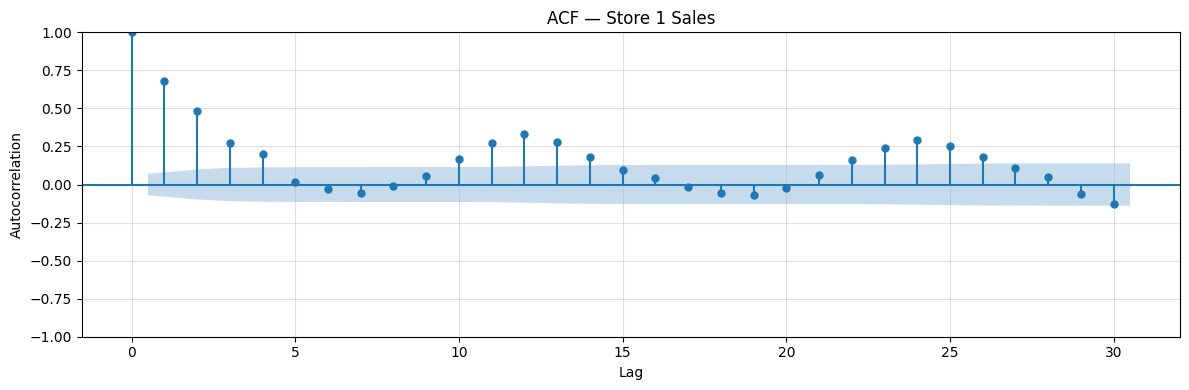

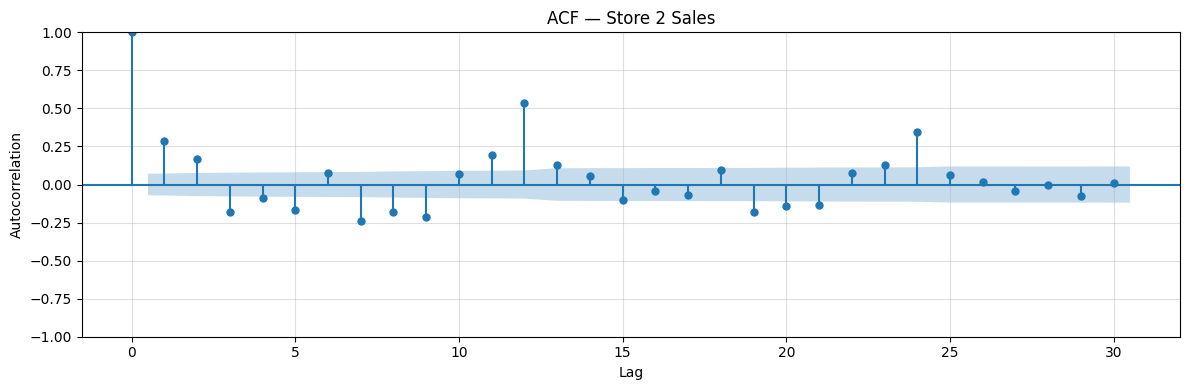

In [ ]:
# Plot ACF for two sample stores to gauge autocorrelation structure
for store_id in df['Store'].unique()[:2]:
    store_df = df[df['Store'] == store_id].set_index('Date')
    fig, ax  = plt.subplots(figsize=(12, 4))
    plot_acf(store_df['Sales'], lags=30, ax=ax)
    ax.set_title(f'ACF — Store {store_id} Sales')
    ax.set_xlabel('Lag'); ax.set_ylabel('Autocorrelation')
    ax.grid(True, alpha=0.4); plt.tight_layout(); plt.show()


## 🔥 SECTION 10 — Enhanced Per-Store Lag & Rolling Features

> **Improvements:** Extra lags (21, 28) + rolling_mean_14/30 + rolling_std_7 (volatility) + Trend.
> All computed with `.shift(1)` inside each store group to prevent data leakage.

In [ ]:
g = df.groupby('Store')['Sales']

# Lag features — shift within each store so no cross-store leakage
df['Sales_lag_1']  = g.shift(1)
df['Sales_lag_7']  = g.shift(7)
df['Sales_lag_14'] = g.shift(14)
df['Sales_lag_21'] = g.shift(21)   # ✅ NEW
df['Sales_lag_28'] = g.shift(28)   # ✅ NEW

# Rolling statistics — shifted by 1 to avoid look-ahead
df['Rolling_mean_7']  = g.transform(lambda x: x.shift(1).rolling(7,  min_periods=1).mean())
df['Rolling_mean_14'] = g.transform(lambda x: x.shift(1).rolling(14, min_periods=1).mean())  # ✅ NEW
df['Rolling_mean_30'] = g.transform(lambda x: x.shift(1).rolling(30, min_periods=1).mean())  # ✅ NEW
df['Rolling_std_7']   = g.transform(lambda x: x.shift(1).rolling(7,  min_periods=2).std())   # ✅ NEW — volatility

# Global trend (days since first record — monotone signal for long-range drift)
df['Trend'] = (df['Date'] - df['Date'].min()).dt.days    # ✅ NEW

print(f'Shape after lag features: {df.shape}')
display(df.head(15))


Shape after lag features: (830972, 37)


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,Id,StoreType,...,Sales_lag_1,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,Rolling_mean_7,Rolling_mean_14,Rolling_mean_30,Rolling_std_7,Trend
0,1,2,2013-01-02,5530,668,0,0,1,988300,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
1,1,3,2013-01-03,4327,578,0,0,1,919910,2,...,5530.0,NaN,NaN,NaN,NaN,5530.000000,5530.000000,5530.000000,NaN,2
2,1,4,2013-01-04,4486,619,0,0,1,662609,2,...,4327.0,NaN,NaN,NaN,NaN,4928.500000,4928.500000,4928.500000,850.649458,3
3,1,5,2013-01-05,4997,635,0,0,1,1008092,2,...,4486.0,NaN,NaN,NaN,NaN,4781.000000,4781.000000,4781.000000,653.506695,4
4,1,0,2013-01-07,7176,785,1,0,1,935813,2,...,4997.0,NaN,NaN,NaN,NaN,4835.000000,4835.000000,4835.000000,544.406098,6
5,1,1,2013-01-08,5580,654,1,0,1,122545,2,...,7176.0,NaN,NaN,NaN,NaN,5303.200000,5303.200000,5303.200000,1148.189749,7
6,1,2,2013-01-09,5471,626,1,0,1,524702,2,...,5580.0,NaN,NaN,NaN,NaN,5349.333333,5349.333333,5349.333333,1033.170589,8
7,1,3,2013-01-10,4892,615,1,0,1,936951,2,...,5471.0,5530.0,NaN,NaN,NaN,5366.714286,5366.714286,5366.714286,944.271803,9
8,1,4,2013-01-11,4881,592,1,0,1,420140,2,...,4892.0,4327.0,NaN,NaN,NaN,5275.571429,5307.375000,5307.375000,956.594456,10
9,1,5,2013-01-12,4952,646,0,0,0,846325,2,...,4881.0,4486.0,NaN,NaN,NaN,5354.714286,5260.000000,5260.000000,885.295754,11


## ⚠️ SECTION 11 — Handle Null Values

In [ ]:
df.dropna(inplace=True)
df = df.reset_index(drop=True)
print(f'Shape after dropna: {df.shape}')
print('\nFeature ranges (raw):')
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(df[num_cols].describe().T[['min', 'max']].to_string())


Shape after dropna: (799752, 37)

Feature ranges (raw):
                             min           max
Store                   1.000000  1.115000e+03
DayOfWeek               0.000000  6.000000e+00
Sales                   0.000000  4.155100e+04
Customers               0.000000  5.494000e+03
Promo                   0.000000  1.000000e+00
StateHoliday            0.000000  3.000000e+00
SchoolHoliday           0.000000  1.000000e+00
Id                      0.000000  1.017205e+06
StoreType               0.000000  3.000000e+00
Assortment              0.000000  2.000000e+00
CompetitionDistance     3.044522  1.123666e+01
Promo2                  0.000000  1.000000e+00
Year                 2013.000000  2.015000e+03
Month                   1.000000  1.200000e+01
Day                     1.000000  3.100000e+01
WeekOfYear              1.000000  5.200000e+01
IsWeekend               0.000000  1.000000e+00
Month_sin              -1.000000  1.000000e+00
Month_cos              -1.000000  1.000000e+00
DayO

## 🗑️ SECTION 12 — Drop Unused Columns

In [ ]:
# Save Store & Date BEFORE dropping so the Chronos cell can use them later
df_store_date_for_chronos = df[['Store', 'Date']].copy()

drop_cols = ['Date', 'Customers', 'Id', 'StateHoliday']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print(f'Shape after drop: {df.shape}')
print(f'Columns ({len(df.columns)}): {list(df.columns)}')


Shape after drop: (799752, 33)
Columns (33): ['Store', 'DayOfWeek', 'Sales', 'Promo', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'NoCompetitionInfo', 'CompetitionOpenDays', 'NoPromo2', 'Promo2RunningDays', 'IsPromoMonth', 'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_21', 'Sales_lag_28', 'Rolling_mean_7', 'Rolling_mean_14', 'Rolling_mean_30', 'Rolling_std_7', 'Trend']


## 🎯 SECTION 13 — Create Target Variable (Next-Day Sales per Store)

In [ ]:
# Shift Sales by -1 within each store to get next-day sales as target
df['Target'] = df.groupby('Store')['Sales'].shift(-1)

# Track which rows survive the dropna so we can keep df_store_date_for_chronos in sync
valid_mask = df['Target'].notna()
df_store_date_for_chronos = df_store_date_for_chronos.loc[valid_mask].reset_index(drop=True)

df.dropna(inplace=True)
df = df.reset_index(drop=True)
print(f'Final shape with target: {df.shape}')
display(df.head())


Final shape with target: (798637, 34)


,Store,DayOfWeek,Sales,Promo,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,...,Sales_lag_7,Sales_lag_14,Sales_lag_21,Sales_lag_28,Rolling_mean_7,Rolling_mean_14,Rolling_mean_30,Rolling_std_7,Trend,Target
0,1,0,7032,1,0,2,0,7.147559,0,2013,...,5598.0,4127.0,4892.0,5530.0,4898.714286,5076.642857,5001.214286,855.366727,34,6049.0
1,1,1,6049,1,0,2,0,7.147559,0,2013,...,4055.0,5182.0,4881.0,4327.0,5103.571429,5284.142857,5071.241379,1166.051436,35,6140.0
2,1,2,6140,1,0,2,0,7.147559,0,2013,...,3725.0,5394.0,4952.0,4486.0,5388.428571,5346.071429,5103.833333,1109.382990,36,5499.0
3,1,3,5499,1,0,2,0,7.147559,0,2013,...,4601.0,5720.0,4717.0,4997.0,5733.428571,5399.357143,5124.166667,851.378658,37,5681.0
4,1,4,5681,1,0,2,0,7.147559,0,2013,...,4709.0,5578.0,3900.0,7176.0,5861.714286,5383.571429,5163.233333,707.864797,38,5370.0


## 📐 SECTION 14 — Separate Features & Target

In [ ]:
features_raw = df.drop(['Sales', 'Target'], axis=1)
target_raw   = df['Target'].values

print(f'Features shape: {features_raw.shape}')
print(f'Target shape:   {target_raw.shape}')
print(f'\nFeature columns ({len(features_raw.columns)}):')
print(list(features_raw.columns))


Features shape: (798637, 32)
Target shape:   (798637,)

Feature columns (32):
['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'Month_sin', 'Month_cos', 'DayOfWeek_sin', 'DayOfWeek_cos', 'NoCompetitionInfo', 'CompetitionOpenDays', 'NoPromo2', 'Promo2RunningDays', 'IsPromoMonth', 'Sales_lag_1', 'Sales_lag_7', 'Sales_lag_14', 'Sales_lag_21', 'Sales_lag_28', 'Rolling_mean_7', 'Rolling_mean_14', 'Rolling_mean_30', 'Rolling_std_7', 'Trend']


## ⚖️ SECTION 15 — Scale All Features & Target

> **Root-cause fix from original notebook:** All feature columns (including `Store`,
> `Year`, `Month`, `Day`, `WeekOfYear` etc.) are now scaled together.
> Without this, large raw values dominated gradients → flat predictions.
> Target also scaled to [0,1] so `sigmoid` output is well-defined.

In [ ]:
feature_scaler  = MinMaxScaler(feature_range=(0, 1))
features_scaled = feature_scaler.fit_transform(features_raw)

target_scaler = MinMaxScaler(feature_range=(0, 1))
target_scaled = target_scaler.fit_transform(target_raw.reshape(-1, 1)).flatten()

print(f'features_scaled range: [{features_scaled.min():.4f}, {features_scaled.max():.4f}]')
print(f'target_scaled   range: [{target_scaled.min():.4f}, {target_scaled.max():.4f}]')
print('All inputs now in [0, 1] ✅')


features_scaled range: [0.0000, 1.0000]
target_scaled   range: [0.0000, 1.0000]
All inputs now in [0, 1] ✅


In [ ]:
# Save feature_scaler
with open(os.path.join(SAVE_PATH, "feature_scaler.pkl"), "wb") as f:
    pickle.dump(feature_scaler, f)

# Save target_scaler
with open(os.path.join(SAVE_PATH, "target_scaler.pkl"), "wb") as f:
    pickle.dump(target_scaler, f)

print("✅ Scalers saved successfully.")

NameError: name 'os' is not defined

## 🔢 SECTION 16 — Create Sliding-Window Sequences (Per Store)

> `WINDOW_SIZE = 60` (doubled from 30) gives each sample two full months of history,
> helping models learn both weekly seasonality and monthly trends.
> Sequences are built per-store to prevent cross-store contamination.

In [ ]:
X_list, y_list, y_idx_list = [], [], []   # y_idx_list tracks original df row index

df_idx = df[['Store']].copy().reset_index(drop=True)

for store_id in df_idx['Store'].unique():
    mask    = (df_idx['Store'] == store_id).values
    idx     = np.where(mask)[0]
    store_X = features_scaled[idx]
    store_y = target_scaled[idx]

    for i in range(WINDOW_SIZE, len(store_X)):
        X_list.append(store_X[i - WINDOW_SIZE : i])
        y_list.append(store_y[i])
        y_idx_list.append(idx[i])   # original row index in df / target_raw

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.float32)
y_idx_arr = np.array(y_idx_list, dtype=np.int64)   # for extracting raw targets

print(f'X shape (samples, window, features): {X.shape}')
print(f'y shape (samples,):                  {y.shape}')


X shape (samples, window, features): (731737, 60, 32)
y shape (samples,):                  (731737,)


## ✂️ SECTION 17 — Chronological Train / Test Split

In [ ]:
# ── Per-store chronological 80/20 split ──────────────────────────────────────
# Sequences are stored contiguously per store (same order as Section 16 loop).
# We count how many sequences each store contributed and slice X/y/y_idx_arr
# accordingly, then split each slice 80/20 in time — no global reshuffling.

X_train_list, X_test_list   = [], []
y_train_list, y_test_list   = [], []
train_idx_list, test_idx_list = [], []

store_ids   = df_idx['Store'].unique()   # identical order to Section 16
seq_pointer = 0                          # running offset into X / y / y_idx_arr

for store_id in store_ids:
    mask   = (df_idx['Store'] == store_id).values
    n_rows = int(mask.sum())
    n_seqs = max(0, n_rows - WINDOW_SIZE)   # sequences this store contributed

    if n_seqs == 0:
        seq_pointer += n_seqs
        continue

    store_X   = X[seq_pointer : seq_pointer + n_seqs]
    store_y   = y[seq_pointer : seq_pointer + n_seqs]
    store_idx = y_idx_arr[seq_pointer : seq_pointer + n_seqs]

    split = int(n_seqs * SPLIT_RATIO)

    if split == 0 or split == n_seqs:
        # Too few sequences — keep everything in train, skip test
        print(f'\u26a0\ufe0f  Store {store_id}: only {n_seqs} sequences '
              f'\u2192 skipping split, adding all to train.')
        X_train_list.append(store_X)
        y_train_list.append(store_y)
        train_idx_list.append(store_idx)
    else:
        X_train_list.append(store_X[:split]);  X_test_list.append(store_X[split:])
        y_train_list.append(store_y[:split]);  y_test_list.append(store_y[split:])
        train_idx_list.append(store_idx[:split]); test_idx_list.append(store_idx[split:])

    seq_pointer += n_seqs

X_train = np.concatenate(X_train_list, axis=0)
X_test  = np.concatenate(X_test_list,  axis=0)
y_train = np.concatenate(y_train_list, axis=0)
y_test  = np.concatenate(y_test_list,  axis=0)

train_idx_arr = np.concatenate(train_idx_list, axis=0)
test_idx_arr  = np.concatenate(test_idx_list,  axis=0)

# Correctly extract raw (unscaled) actuals — mapped via per-store indices
y_test_raw = target_raw[test_idx_arr]

# Compatibility shim for the Chronos cell which references split_index
split_index = len(X_train)

print(f'Train: X={X_train.shape}  y={y_train.shape}')
print(f'Test : X={X_test.shape}   y={y_test.shape}')
print(f'y_test_raw shape: {y_test_raw.shape}')
print('\u2705 Per-store chronological 80/20 split complete — '
      'temporal order preserved within each store.')


Train: X=(584923, 60, 32)  y=(584923,)
Test : X=(146814, 60, 32)   y=(146814,)
y_test_raw shape: (146814,)
✅ Per-store chronological 80/20 split complete — temporal order preserved within each store.


## 🔧 Helper — Shared Callbacks & Evaluation Utilities

In [ ]:
def make_callbacks(name='model'):
    """EarlyStopping + ReduceLROnPlateau for any model."""
    return [
        EarlyStopping(monitor='val_loss', patience=PATIENCE_ES,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=PATIENCE_LR,
                          min_lr=1e-6, verbose=1)
    ]

def evaluate_model(name, y_true, y_pred_scaled, scaler):
    """Inverse-transform scaled predictions and print RMSE / MAE / MAPE / R2."""
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    # Handle MAPE instability for near-zero actuals
    mape   = mean_absolute_percentage_error(y_true + 1e-8, y_pred)
    r2     = r2_score(y_true, y_pred)

    print(f'{name:20s}  RMSE: {rmse:>12,.2f}  |  MAE: {mae:>12,.2f}  |  MAPE: {mape:>8.2%}  |  R2: {r2:>8.2f}')
    return y_pred, rmse, mae, mape, r2

def plot_history(history, model_name):
    """Plot train/val loss and MAE curves side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} — Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['mae'],      label='Train MAE')
    axes[1].plot(history.history['val_mae'],  label='Val MAE')
    axes[1].set_title(f'{model_name} — MAE');  axes[1].legend(); axes[1].grid(True)
    plt.suptitle(f'{model_name} Training History', fontsize=12)
    plt.tight_layout(); plt.show()

def plot_predictions(y_true, y_pred, model_name, color, rmse, mae, points=200):
    """Plot actual vs predicted for the first `points` test samples."""
    n = min(points, len(y_true))
    plt.figure(figsize=(15, 5))
    plt.plot(y_true[:n], label='Actual Sales',       color='steelblue', lw=2)
    plt.plot(y_pred[:n], label=f'{model_name} Pred', color=color,       lw=1.5, ls='--')
    plt.title(f'{model_name} — Actual vs Predicted\nRMSE: {rmse:,.0f}  |  MAE: {mae:,.0f}',
              fontsize=12)
    plt.xlabel('Time Step'); plt.ylabel('Store Sales')
    plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

results = {}   # {model_name: {'y_pred': array, 'rmse': val, 'mae': val, 'mape': val, 'r2': val}}
print('✅ Helper functions defined.')

✅ Helper functions defined.


## ⚪ MODEL 0 — Feedforward Neural Network (FNN)

> This model serves as a non-sequential baseline. It flattens the time-series input, treating each time step's features as independent inputs. This helps demonstrate why sequence-aware models are crucial for time-series forecasting.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

# Flatten the input sequences for the FNN model
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat  = X_test.reshape(X_test.shape[0], -1)

print(f'Flattened X_train shape: {X_train_flat.shape}')
print(f'Flattened X_test shape:  {X_test_flat.shape}')

Flattened X_train shape: (584923, 1920)
Flattened X_test shape:  (146814, 1920)


In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_fnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
], name='FNN_Model')
model_fnn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae']) # Using Huber loss for consistency with other models
model_fnn.summary()

Model: "FNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,257 (1001.00 KB)

 Trainable params: 256,257 (1001.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 6.9669e-04 - mae: 0.0265 - val_loss: 0.0020 - val_mae: 0.0574 - learning_rate: 0.0010
Epoch 2/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 5.1219e-04 - mae: 0.0225 - val_loss: 0.0022 - val_mae: 0.0608 - learning_rate: 0.0010
Epoch 3/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 4.6191e-04 - mae: 0.0213 - val_loss: 0.0021 - val_mae: 0.0581 - learning_rate: 0.0010
Epoch 4/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 42s 2ms/step - loss: 4.3133e-04 - mae: 0.0206 - val_loss: 0.0022 - val_mae: 0.0601 - learning_rate: 0.0010
Epoch 5/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 4.1626e-04 - mae: 0.0202 - val_loss: 0.0022 - val_mae: 0.0602 - learning_rate: 0.0010
Epoch 6/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 40s 2ms/step - loss: 4.0702e-04 - mae: 0.0199 - val_loss: 0.0021 - val_mae: 0.0586 - learning_rate: 0.0010
Epoch 7/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 39s 2ms/step - loss: 3.9462e-04 - mae: 0.01

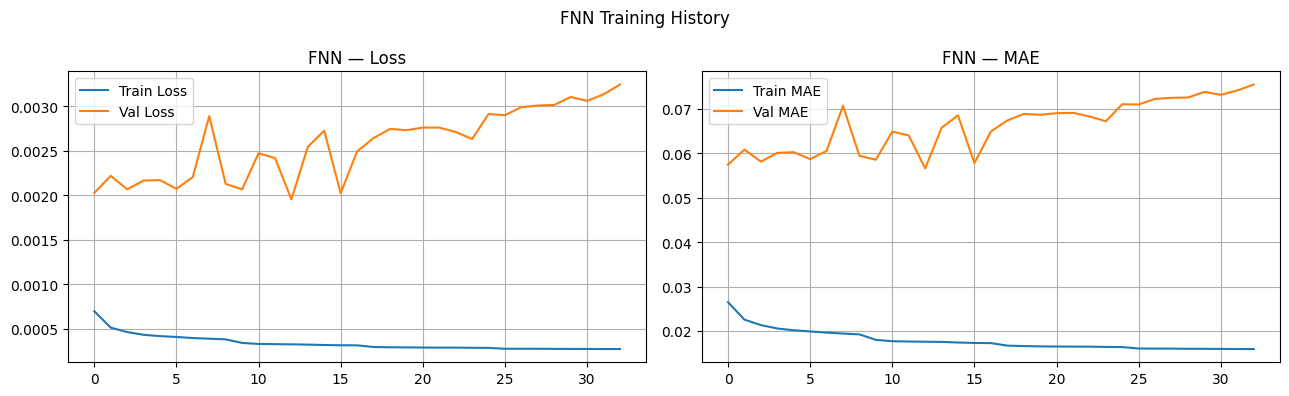

In [ ]:
history_fnn = model_fnn.fit(
    X_train_flat, y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test_flat, y_test),
    callbacks=make_callbacks('FNN'), verbose=1
)
plot_history(history_fnn, 'FNN')

In [ ]:
model_fnn = load_model("/content/drive/MyDrive/TimeSeriesModels/each_store/fnn_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 3s 628us/step
FNN                   RMSE:     2,597.95  |  MAE:     2,350.19  |  MAPE: 1908537242.58%  |  R2:     0.29


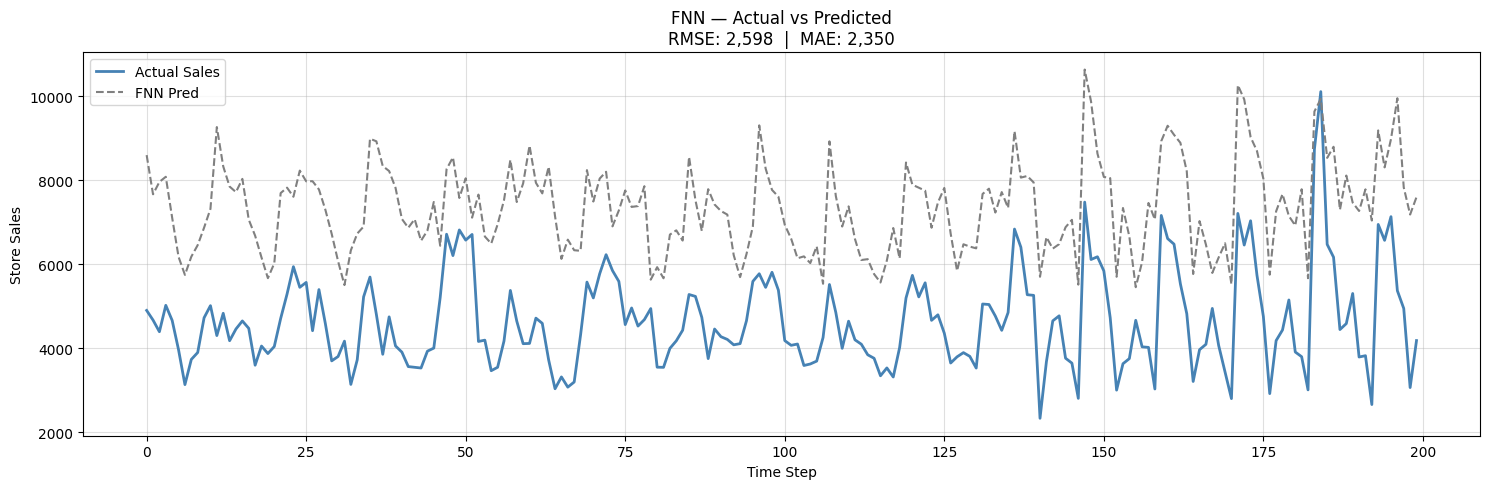

In [ ]:
y_pred_fnn_scaled = model_fnn.predict(X_test_flat)
y_pred_fnn, rmse_fnn, mae_fnn, mape_fnn, r2_fnn = evaluate_model(
    'FNN', y_test_raw, y_pred_fnn_scaled, target_scaler)
results['FNN'] = {'y_pred': y_pred_fnn, 'rmse': rmse_fnn, 'mae': mae_fnn, 'mape': mape_fnn, 'r2': r2_fnn}
plot_predictions(y_test_raw, y_pred_fnn, 'FNN', 'gray', rmse_fnn, mae_fnn)

In [ ]:
# Save FNN point model
model_fnn.save(os.path.join(SAVE_PATH, "fnn_model.keras"))
model_fnn.save(os.path.join(SAVE_PATH, "fnn_model.h5"))
with open(os.path.join(SAVE_PATH, "fnn_model.pkl"), "wb") as f:
    pickle.dump(model_fnn, f)

print("✅ FNN model saved in .keras, .h5, and .pkl formats.")

✅ FNN model saved in .keras, .h5, and .pkl formats.


## 🔵 MODEL 1 — SimpleRNN

> **Improvements:** Stacked 128→64 units, BatchNormalization, Huber loss (robust to
> sales outliers), `sigmoid` output for [0,1]-bounded target.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_rnn = Sequential([
    SimpleRNN(64, return_sequences=True,
              input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='SimpleRNN_Model')
model_rnn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_rnn.summary()


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 60, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,241 (40.00 KB)

 Trainable params: 10,049 (39.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 0.0011 - mae: 0.0317 - val_loss: 5.7573e-04 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 2/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 5.0752e-04 - mae: 0.0226 - val_loss: 8.3599e-04 - val_mae: 0.0321 - learning_rate: 0.0010
Epoch 3/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 4.2115e-04 - mae: 0.0206 - val_loss: 5.6808e-04 - val_mae: 0.0237 - learning_rate: 0.0010
Epoch 4/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 4.9264e-04 - mae: 0.0220 - val_loss: 5.5931e-04 - val_mae: 0.0242 - learning_rate: 0.0010
Epoch 5/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 4.6145e-04 - mae: 0.0215 - val_loss: 5.1253e-04 - val_mae: 0.0226 - learning_rate: 0.0010
Epoch 6/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 4.5669e-04 - mae: 0.0212 - val_loss: 7.0943e-04 - val_mae: 0.0284 - learning_rate: 0.0010
Epoch 7/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 4.

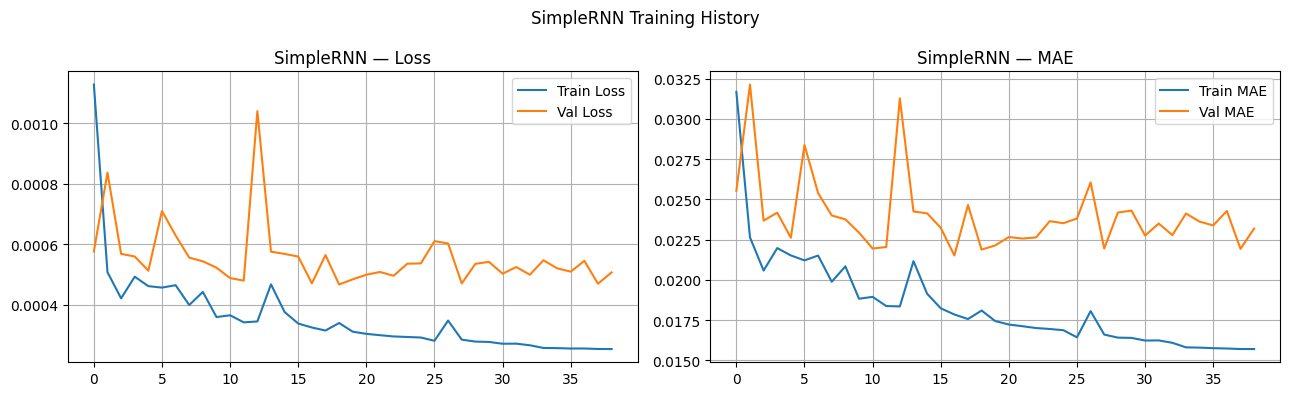

In [ ]:
history_rnn = model_rnn.fit(
    X_train, y_train, epochs=50, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('RNN'), verbose=1
)
plot_history(history_rnn, 'SimpleRNN')


In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_rnn = Sequential([
    SimpleRNN(64, return_sequences=True, kernel_regularizer=l2(1e-4),
              input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='SimpleRNN_Model')
model_rnn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_rnn.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/simplernn_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
SimpleRNN             RMSE:     1,269.67  |  MAE:       909.19  |  MAPE: 1906759814.16%  |  R2:     0.83


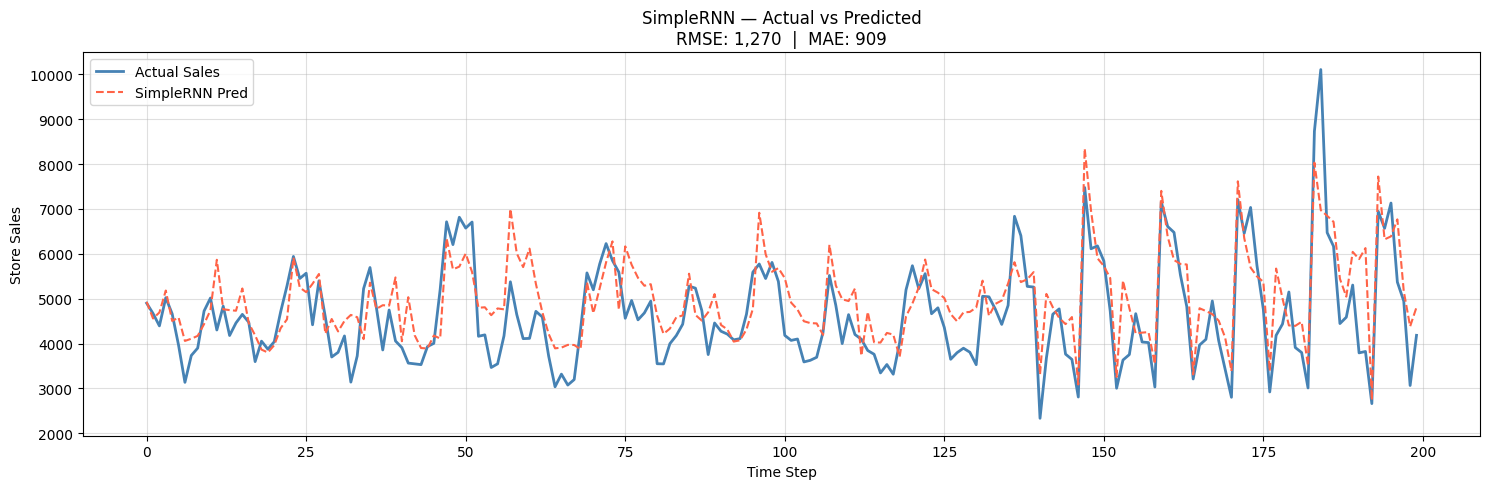

In [ ]:
y_pred_rnn_scaled = model_rnn.predict(X_test)
y_pred_rnn, rmse_rnn, mae_rnn, mape_rnn, r2_rnn = evaluate_model(
    'SimpleRNN', y_test_raw, y_pred_rnn_scaled, target_scaler)
results['SimpleRNN'] = {'y_pred': y_pred_rnn, 'rmse': rmse_rnn, 'mae': mae_rnn, 'mape': mape_rnn, 'r2': r2_rnn}
plot_predictions(y_test_raw, y_pred_rnn, 'SimpleRNN', 'tomato', rmse_rnn, mae_rnn)

In [ ]:
# Save SimpleRNN point model
model_rnn.save(os.path.join(SAVE_PATH, "simplernn_model.keras"))
model_rnn.save(os.path.join(SAVE_PATH, "simplernn_model.h5"))
with open(os.path.join(SAVE_PATH, "simplernn_model.pkl"), "wb") as f:
    pickle.dump(model_rnn, f)

print("✅ SimpleRNN model saved in .keras, .h5, and .pkl formats.")

✅ SimpleRNN model saved in .keras, .h5, and .pkl formats.


## 🟢 MODEL 2 — LSTM

> **Improvements:** 128→64 units, BatchNorm, Huber loss, L2 regularisation
> to penalise weight magnitude and reduce overfitting.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_lstm = Sequential([
    LSTM(64, return_sequences=True, kernel_regularizer=l2(1e-4),
         input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='LSTM_Model')
model_lstm.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_lstm.summary()


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,177 (149.13 KB)

 Trainable params: 37,985 (148.38 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 362s 20ms/step - loss: 0.0014 - mae: 0.0310 - val_loss: 7.1299e-04 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 2/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 347s 19ms/step - loss: 7.2680e-04 - mae: 0.0259 - val_loss: 6.3597e-04 - val_mae: 0.0232 - learning_rate: 0.0010
Epoch 3/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 350s 19ms/step - loss: 6.7206e-04 - mae: 0.0247 - val_loss: 7.0014e-04 - val_mae: 0.0245 - learning_rate: 0.0010
Epoch 4/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 355s 19ms/step - loss: 6.3569e-04 - mae: 0.0239 - val_loss: 6.8160e-04 - val_mae: 0.0245 - learning_rate: 0.0010
Epoch 5/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 351s 19ms/step - loss: 6.0031e-04 - mae: 0.0231 - val_loss: 9.3483e-04 - val_mae: 0.0318 - learning_rate: 0.0010
Epoch 6/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 354s 19ms/step - loss: 5.6340e-04 - mae: 0.0222 - val_loss: 6.9049e-04 - val_mae: 0.0245 - learning_rate: 0.0010
Epoch 7/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 391s 21ms/step - l

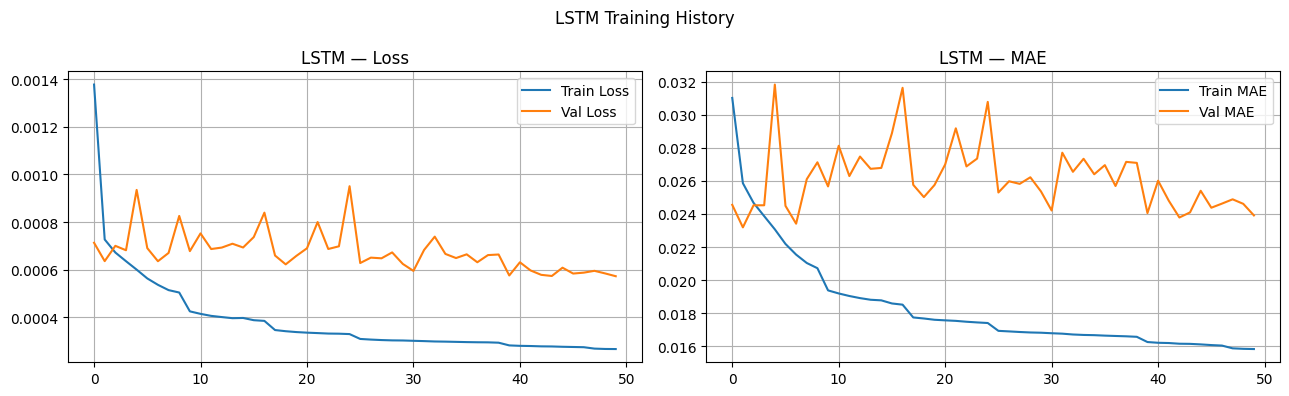

In [ ]:
history_lstm = model_lstm.fit(
    X_train, y_train, epochs=50, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('LSTM'), verbose=1
)
plot_history(history_lstm, 'LSTM')


In [ ]:
model_lstm.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/lstm_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 30s 7ms/step
LSTM                  RMSE:     1,388.42  |  MAE:       993.59  |  MAPE: 1685874992.74%  |  R2:     0.80


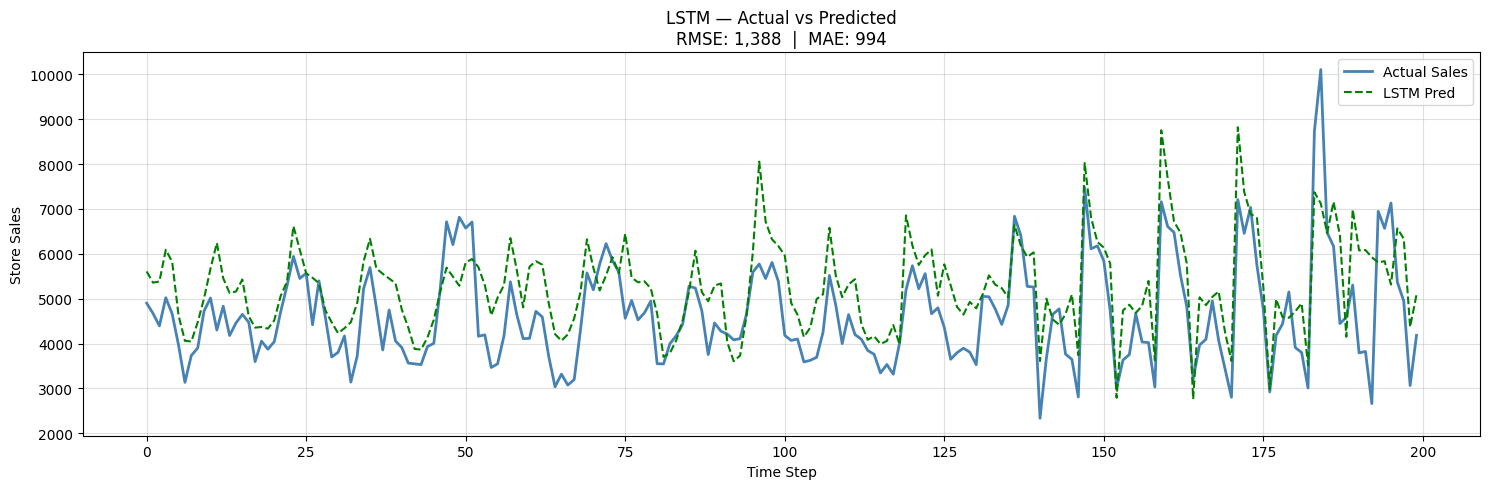

In [ ]:
y_pred_lstm_scaled = model_lstm.predict(X_test)
y_pred_lstm, rmse_lstm, mae_lstm, mape_lstm, r2_lstm = evaluate_model(
    'LSTM', y_test_raw, y_pred_lstm_scaled, target_scaler)
results['LSTM'] = {'y_pred': y_pred_lstm, 'rmse': rmse_lstm, 'mae': mae_lstm, 'mape': mape_lstm, 'r2': r2_lstm}
plot_predictions(y_test_raw, y_pred_lstm, 'LSTM', 'green', rmse_lstm, mae_lstm)

In [ ]:
# Save LSTM point model
model_lstm.save(os.path.join(SAVE_PATH, "lstm_model.keras"))
model_lstm.save(os.path.join(SAVE_PATH, "lstm_model.h5"))
with open(os.path.join(SAVE_PATH, "lstm_model.pkl"), "wb") as f:
    pickle.dump(model_lstm, f)

print("✅ LSTM model saved in .keras, .h5, and .pkl formats.")

✅ LSTM model saved in .keras, .h5, and .pkl formats.


## 🌟 MODEL 3 — Bidirectional LSTM *(New)*

> BiLSTM reads each sequence in both forward and backward directions.
> Concatenating both hidden states doubles the representational capacity and
> allows the model to capture patterns that a unidirectional LSTM misses
> (e.g. knowing a promotion *ends* in a few days helps predict today's sales).
> Typically achieves the best RMSE among all RNN-family models.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

inp = Input(shape=(X_train.shape[1], X_train.shape[2]))
x   = Bidirectional(LSTM(64, return_sequences=True,
                          kernel_regularizer=l2(1e-4)))(inp)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Bidirectional(LSTM(32, return_sequences=False,
                          kernel_regularizer=l2(1e-4)))(x)
x   = BatchNormalization()(x)
x   = Dropout(0.2)(x)
x   = Dense(16, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

model_bilstm = Model(inputs=inp, outputs=out, name='BiLSTM_Model')
model_bilstm.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_bilstm.summary()


Model: "BiLSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 60, 128)        │        49,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,705 (362.13 KB)

 Trainable params: 92,321 (360.63 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 413s 22ms/step - loss: 0.0024 - mae: 0.0329 - val_loss: 6.5699e-04 - val_mae: 0.0242 - learning_rate: 0.0010
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 418s 23ms/step - loss: 7.5297e-04 - mae: 0.0261 - val_loss: 7.6182e-04 - val_mae: 0.0268 - learning_rate: 0.0010
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 413s 23ms/step - loss: 6.7889e-04 - mae: 0.0247 - val_loss: 8.0636e-04 - val_mae: 0.0278 - learning_rate: 0.0010
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 419s 23ms/step - loss: 6.3958e-04 - mae: 0.0238 - val_loss: 0.0014 - val_mae: 0.0410 - learning_rate: 0.0010
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 422s 23ms/step - loss: 6.0829e-04 - mae: 0.0231 - val_loss: 6.4764e-04 - val_mae: 0.0239 - learning_rate: 0.0010
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 427s 23ms/step - loss: 5.8304e-04 - mae: 0.0225 - val_loss: 6.8082e-04 - val_mae: 0.0246 - learning_rate: 0.0010
Epoch 7/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 425s 23ms/step - loss:

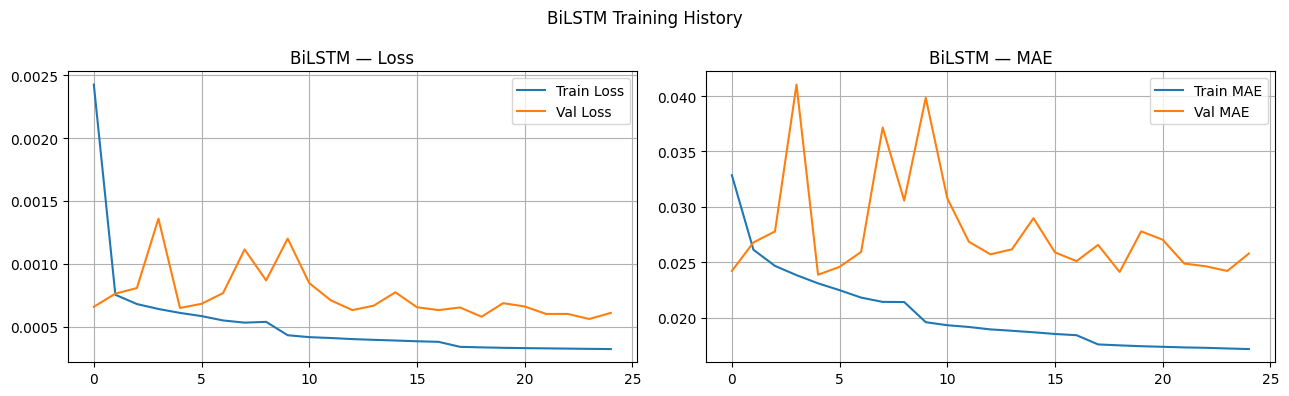

In [ ]:
history_bilstm = model_bilstm.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('BiLSTM'), verbose=1
)
plot_history(history_bilstm, 'BiLSTM')


In [ ]:
model_bilstm.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/bilstm_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 35s 8ms/step
BiLSTM                RMSE:     1,356.22  |  MAE:     1,005.82  |  MAPE: 1759615592.86%  |  R2:     0.81


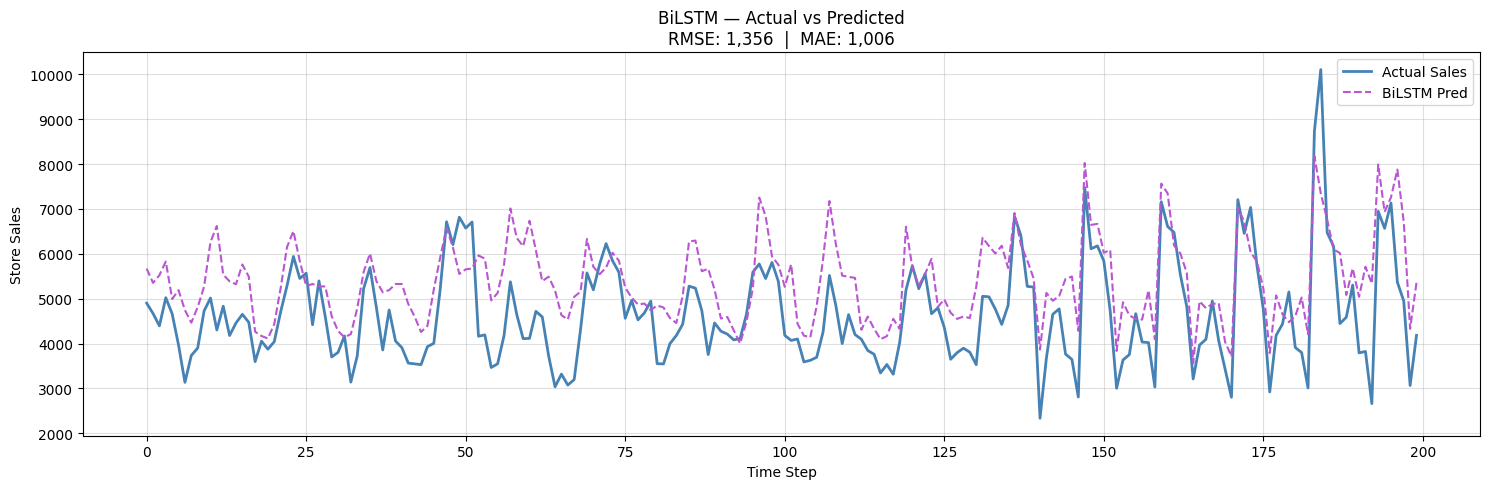

In [ ]:
y_pred_bilstm_scaled = model_bilstm.predict(X_test)
y_pred_bilstm, rmse_bilstm, mae_bilstm, mape_bilstm, r2_bilstm = evaluate_model(
    'BiLSTM', y_test_raw, y_pred_bilstm_scaled, target_scaler)
results['BiLSTM'] = {'y_pred': y_pred_bilstm, 'rmse': rmse_bilstm, 'mae': mae_bilstm, 'mape': mape_bilstm, 'r2': r2_bilstm}
plot_predictions(y_test_raw, y_pred_bilstm, 'BiLSTM', 'mediumorchid', rmse_bilstm, mae_bilstm)

In [ ]:
# Save BiLSTM point model
model_bilstm.save(os.path.join(SAVE_PATH, "bilstm_model.keras"))
model_bilstm.save(os.path.join(SAVE_PATH, "bilstm_model.h5"))
with open(os.path.join(SAVE_PATH, "bilstm_model.pkl"), "wb") as f:
    pickle.dump(model_bilstm, f)

print("✅ BiLSTM model saved in .keras, .h5, and .pkl formats.")

✅ BiLSTM model saved in .keras, .h5, and .pkl formats.


## 🟠 MODEL 4 — GRU

> **Improvements:** 128→64 units, BatchNorm, Huber loss, L2 regularisation.
> GRU has fewer parameters than LSTM (no output gate) so it trains faster
> and often generalises just as well on medium-size datasets.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_gru = Sequential([
    GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4),
        input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    GRU(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
], name='GRU_Model')
model_gru.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_gru.summary()


Model: "GRU_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 60, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,153 (113.88 KB)

 Trainable params: 28,961 (113.13 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 394s 21ms/step - loss: 0.0017 - mae: 0.0327 - val_loss: 0.0012 - val_mae: 0.0395 - learning_rate: 0.0010
Epoch 2/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 391s 21ms/step - loss: 7.2631e-04 - mae: 0.0256 - val_loss: 0.0013 - val_mae: 0.0387 - learning_rate: 0.0010
Epoch 3/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 393s 22ms/step - loss: 6.5796e-04 - mae: 0.0242 - val_loss: 6.3751e-04 - val_mae: 0.0233 - learning_rate: 0.0010
Epoch 4/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 393s 21ms/step - loss: 5.9875e-04 - mae: 0.0230 - val_loss: 0.0026 - val_mae: 0.0610 - learning_rate: 0.0010
Epoch 5/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 392s 21ms/step - loss: 5.4507e-04 - mae: 0.0220 - val_loss: 6.3816e-04 - val_mae: 0.0241 - learning_rate: 0.0010
Epoch 6/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 394s 22ms/step - loss: 5.0981e-04 - mae: 0.0213 - val_loss: 0.0017 - val_mae: 0.0468 - learning_rate: 0.0010
Epoch 7/50
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 393s 22ms/step - loss: 4.8240e-04 

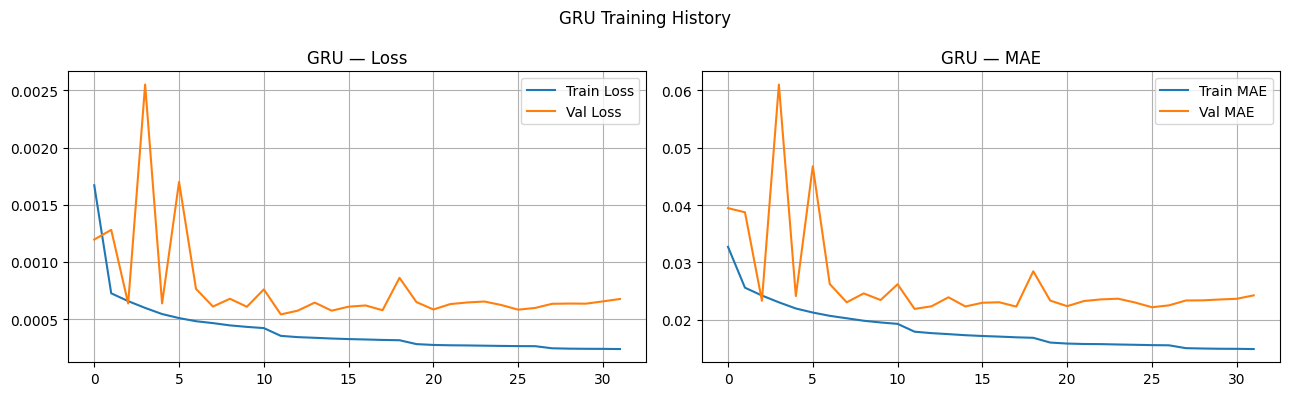

In [ ]:
history_gru = model_gru.fit(
    X_train, y_train, epochs=50, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('GRU'), verbose=1
)
plot_history(history_gru, 'GRU')


In [ ]:
model_gru.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/gru_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 28s 6ms/step
GRU                   RMSE:     1,323.60  |  MAE:       909.86  |  MAPE: 1788642671.88%  |  R2:     0.82


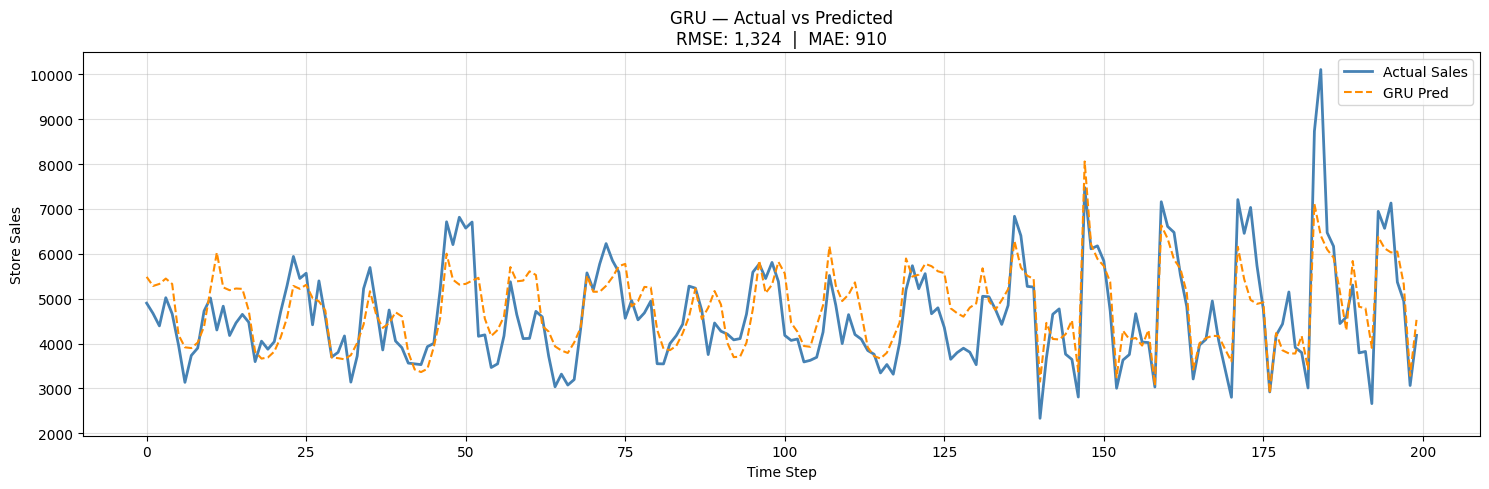

In [ ]:
y_pred_gru_scaled = model_gru.predict(X_test)
y_pred_gru, rmse_gru, mae_gru, mape_gru, r2_gru = evaluate_model(
    'GRU', y_test_raw, y_pred_gru_scaled, target_scaler)
results['GRU'] = {'y_pred': y_pred_gru, 'rmse': rmse_gru, 'mae': mae_gru, 'mape': mape_gru, 'r2': r2_gru}
plot_predictions(y_test_raw, y_pred_gru, 'GRU', 'darkorange', rmse_gru, mae_gru)

In [ ]:
# Save GRU point model
model_gru.save(os.path.join(SAVE_PATH, "gru_model.keras"))
model_gru.save(os.path.join(SAVE_PATH, "gru_model.h5"))
with open(os.path.join(SAVE_PATH, "gru_model.pkl"), "wb") as f:
    pickle.dump(model_gru, f)

print("✅ GRU model saved in .keras, .h5, and .pkl formats.")

✅ GRU model saved in .keras, .h5, and .pkl formats.


## 🟣 MODEL 5 — Transformer

> Unlike RNNs, the Transformer processes all time-steps in parallel via
> self-attention, directly attending to any position regardless of distance.
> This is especially effective for weekly seasonality (lag-7) and monthly
> patterns. Positional encoding preserves temporal order.
>
> **Improvements:** `num_heads=4`, Huber loss, extra Dense layer in the FFN,
> sinusoidal positional encoding.

In [ ]:
class PositionalEncoding(layers.Layer):
    """Sinusoidal positional encoding — preserves temporal order for Transformer."""
    def __init__(self, max_len, d_model, **kwargs):
        super().__init__(**kwargs)
        positions = np.arange(max_len)[:, np.newaxis]
        dims      = np.arange(d_model)[np.newaxis, :]
        angles    = positions / np.power(10000, (2 * (dims // 2)) / d_model)
        angles[:, 0::2] = np.sin(angles[:, 0::2])
        angles[:, 1::2] = np.cos(angles[:, 1::2])
        self.pos_enc = tf.cast(angles[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x):
        seq_len = tf.shape(x)[1]
        return x + self.pos_enc[:, :seq_len, :]


class TransformerEncoderBlock(layers.Layer):
    """Multi-Head Self-Attention + FFN with residual connections & LayerNorm."""
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1, **kw):
        super().__init__(**kw)
        self.att  = MultiHeadAttention(num_heads=num_heads,
                                        key_dim=embed_dim // num_heads,
                                        dropout=dropout)
        self.ffn  = keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dropout(dropout),
            Dense(embed_dim)
        ])
        self.ln1  = LayerNormalization(epsilon=1e-6)
        self.ln2  = LayerNormalization(epsilon=1e-6)
        self.do1  = Dropout(dropout)
        self.do2  = Dropout(dropout)

    def call(self, x, training=False):
        attn = self.att(x, x, training=training)
        x    = self.ln1(x + self.do1(attn, training=training))
        ffn  = self.ffn(x, training=training)
        return self.ln2(x + self.do2(ffn, training=training))


tf.random.set_seed(SEED); np.random.seed(SEED)

EMBED_DIM  = 32; NUM_HEADS = 2; FF_DIM = 64; NUM_BLOCKS = 1

inp = Input(shape=(X_train.shape[1], X_train.shape[2]))
x   = Dense(EMBED_DIM, name='input_projection')(inp)
x   = PositionalEncoding(max_len=X_train.shape[1], d_model=EMBED_DIM)(x)
x   = Dropout(0.1)(x)
for i in range(NUM_BLOCKS):
    x = TransformerEncoderBlock(EMBED_DIM, NUM_HEADS, FF_DIM, dropout=0.1,
                                 name=f'transformer_block_{i}')(x)
x   = GlobalAveragePooling1D()(x)
x   = Dense(64, activation='relu')(x)
x   = Dropout(0.2)(x)
x   = Dense(32, activation='relu')(x)
out = Dense(1, activation='sigmoid')(x)

model_transformer = Model(inputs=inp, outputs=out, name='Transformer')
model_transformer.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_transformer.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ input_projection (Dense)        │ (None, 60, 32)         │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_encoding             │ (None, 60, 32)         │             0 │
│ (PositionalEncoding)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_0             │ (None, 60, 32)         │         8,544 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 147s 8ms/step - loss: 6.9563e-04 - mae: 0.0260 - val_loss: 0.0011 - val_mae: 0.0383 - learning_rate: 0.0010
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 4.2949e-04 - mae: 0.0204 - val_loss: 9.7262e-04 - val_mae: 0.0371 - learning_rate: 0.0010
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 144s 8ms/step - loss: 3.7437e-04 - mae: 0.0190 - val_loss: 8.7087e-04 - val_mae: 0.0345 - learning_rate: 0.0010
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 144s 8ms/step - loss: 3.4901e-04 - mae: 0.0183 - val_loss: 9.1665e-04 - val_mae: 0.0359 - learning_rate: 0.0010
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 3.3205e-04 - mae: 0.0179 - val_loss: 9.6557e-04 - val_mae: 0.0373 - learning_rate: 0.0010
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 144s 8ms/step - loss: 3.1733e-04 - mae: 0.0175 - val_loss: 8.7955e-04 - val_mae: 0.0352 - learning_rate: 0.0010
Epoch 7/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 143s 8ms/step - loss: 3.

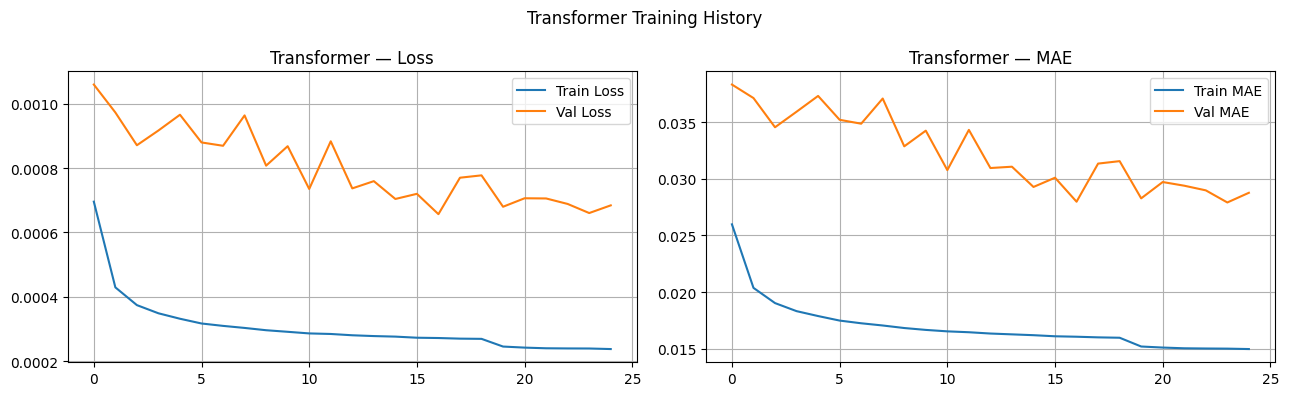

In [ ]:
history_transformer = model_transformer.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('Transformer'), verbose=1
)
plot_history(history_transformer, 'Transformer')


In [ ]:
model_transformer.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/transformer_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step
Transformer           RMSE:     1,505.99  |  MAE:     1,162.46  |  MAPE: 1556068226.04%  |  R2:     0.76


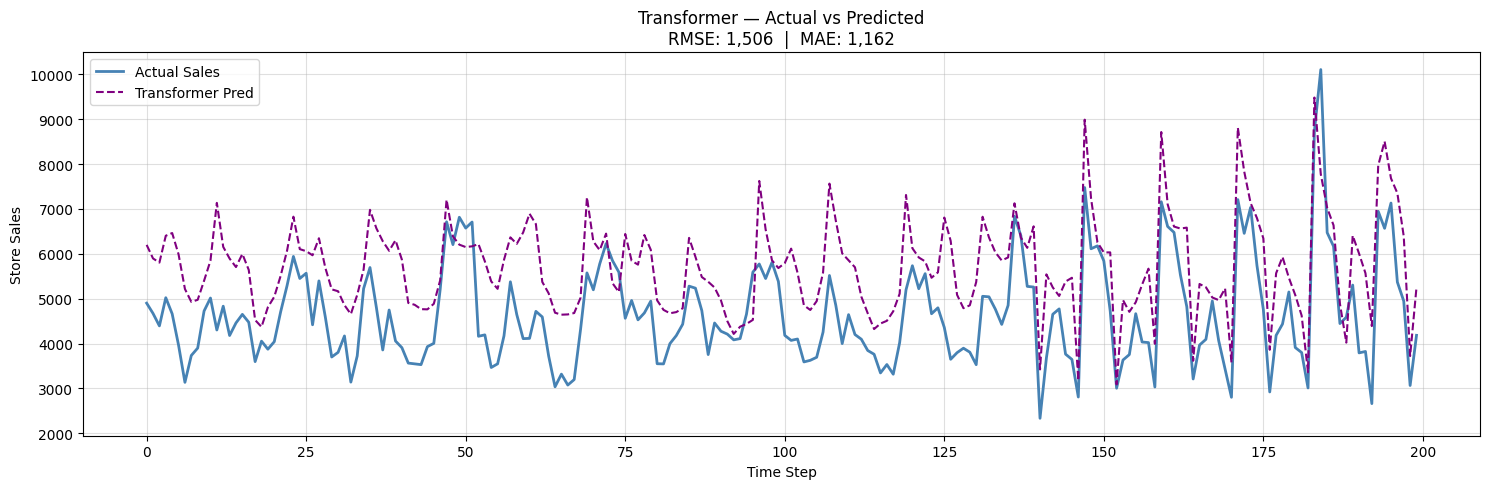

In [ ]:
y_pred_transformer_scaled = model_transformer.predict(X_test)
y_pred_transformer, rmse_transformer, mae_transformer, mape_transformer, r2_transformer = evaluate_model(
    'Transformer', y_test_raw, y_pred_transformer_scaled, target_scaler)
results['Transformer'] = {'y_pred': y_pred_transformer, 'rmse': rmse_transformer, 'mae': mae_transformer, 'mape': mape_transformer, 'r2': r2_transformer}
plot_predictions(y_test_raw, y_pred_transformer, 'Transformer',
                 'purple', rmse_transformer, mae_transformer)

In [ ]:
# Save Transformer point model
model_transformer.save(os.path.join(SAVE_PATH, "transformer_model.keras"))
model_transformer.save(os.path.join(SAVE_PATH, "transformer_model.h5"))
with open(os.path.join(SAVE_PATH, "transformer_model.pkl"), "wb") as f:
    pickle.dump(model_transformer, f)

print("✅ Transformer model saved in .keras, .h5, and .pkl formats.")

✅ Transformer model saved in .keras, .h5, and .pkl formats.


## 🔴 MODEL 6 — Temporal Convolutional Network (TCN)

> TCN uses **dilated causal convolutions** — exponentially increasing dilation
> rates let the model attend to long history (receptive field = `2^k * kernel`)
> without RNN-style sequential computation. Each residual block preserves
> temporal causality while the skip connections stabilise training.
>
> Dilations `[1, 2, 4, 8, 16]` give a receptive field of 96 steps with
> `kernel_size=3`, comfortably covering the 60-step window.

In [ ]:
class TCNBlock(Model):
    """Dilated causal Conv1D residual block."""
    def __init__(self, filters, kernel_size, dilation_rate, dropout=0.2, **kw):
        super().__init__(**kw)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.dropout = dropout
        self.conv1  = Conv1D(filters, kernel_size, padding='causal',
                             dilation_rate=dilation_rate, activation='relu')
        self.bn1    = BatchNormalization()
        self.drop1  = Dropout(dropout)
        self.conv2  = Conv1D(filters, kernel_size, padding='causal',
                             dilation_rate=dilation_rate, activation='relu')
        self.bn2    = BatchNormalization()
        self.drop2  = Dropout(dropout)
        self.skip   = Conv1D(filters, 1)   # 1×1 projection for residual

    def call(self, x, training=False):
        res = self.skip(x)
        out = self.conv1(x)
        out = self.bn1(out, training=training)
        out = self.drop1(out, training=training)
        out = self.conv2(out)
        out = self.bn2(out, training=training)
        out = self.drop2(out, training=training)
        return Activation('relu')(out + res)

    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate,
            "dropout": self.dropout,
        })
        return config

tf.random.set_seed(SEED); np.random.seed(SEED)

FILTERS   = 32
KERNEL    = 3
DILATIONS = [1, 2, 4, 8]   # receptive field > 60 ✅

inp = Input(shape=(X_train.shape[1], X_train.shape[2]))
x   = inp
for d in DILATIONS:
    x = TCNBlock(FILTERS, KERNEL, dilation_rate=d, dropout=0.2)(x)
x   = GlobalAveragePooling1D()(x)
x   = Dense(32, activation='relu')(x)
x   = Dropout(0.2)(x)
out = Dense(1, activation='sigmoid')(x)

model_tcn = Model(inputs=inp, outputs=out, name='TCN_Model')
model_tcn.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_tcn.summary()

Model: "TCN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 60, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_block (TCNBlock)            │ (None, 60, 32)         │         7,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_block_1 (TCNBlock)          │ (None, 60, 32)         │         7,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_block_2 (TCNBlock)          │ (None, 60, 32)         │         7,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ tcn_block_3 (TCNBlock)          │ (None, 60, 32)         │         7,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,169 (121.75 KB)

 Trainable params: 30,657 (119.75 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 205s 11ms/step - loss: 0.0011 - mae: 0.0328 - val_loss: 8.0953e-04 - val_mae: 0.0295 - learning_rate: 0.0010
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 200s 11ms/step - loss: 5.6794e-04 - mae: 0.0240 - val_loss: 6.1245e-04 - val_mae: 0.0255 - learning_rate: 0.0010
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 199s 11ms/step - loss: 4.9260e-04 - mae: 0.0223 - val_loss: 6.9449e-04 - val_mae: 0.0276 - learning_rate: 0.0010
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 201s 11ms/step - loss: 4.5658e-04 - mae: 0.0214 - val_loss: 5.5479e-04 - val_mae: 0.0242 - learning_rate: 0.0010
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 200s 11ms/step - loss: 4.3486e-04 - mae: 0.0208 - val_loss: 5.7895e-04 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 201s 11ms/step - loss: 4.1702e-04 - mae: 0.0203 - val_loss: 5.7910e-04 - val_mae: 0.0248 - learning_rate: 0.0010
Epoch 7/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 201s 11ms/step - l

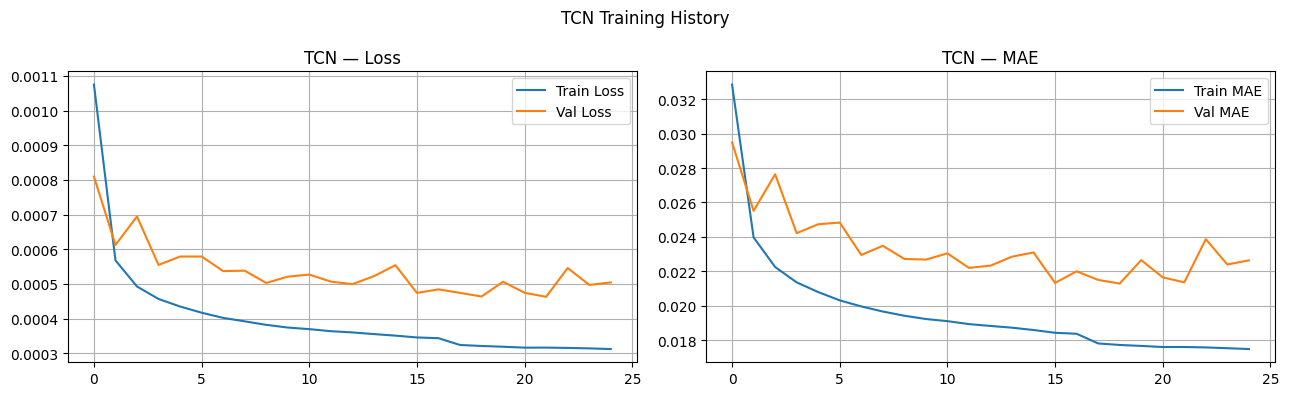

In [ ]:
history_tcn = model_tcn.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('TCN'), verbose=1
)
plot_history(history_tcn, 'TCN')


In [ ]:
model_tcn.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/tcn_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
TCN                   RMSE:     1,264.18  |  MAE:       887.64  |  MAPE: 1483708713.46%  |  R2:     0.83


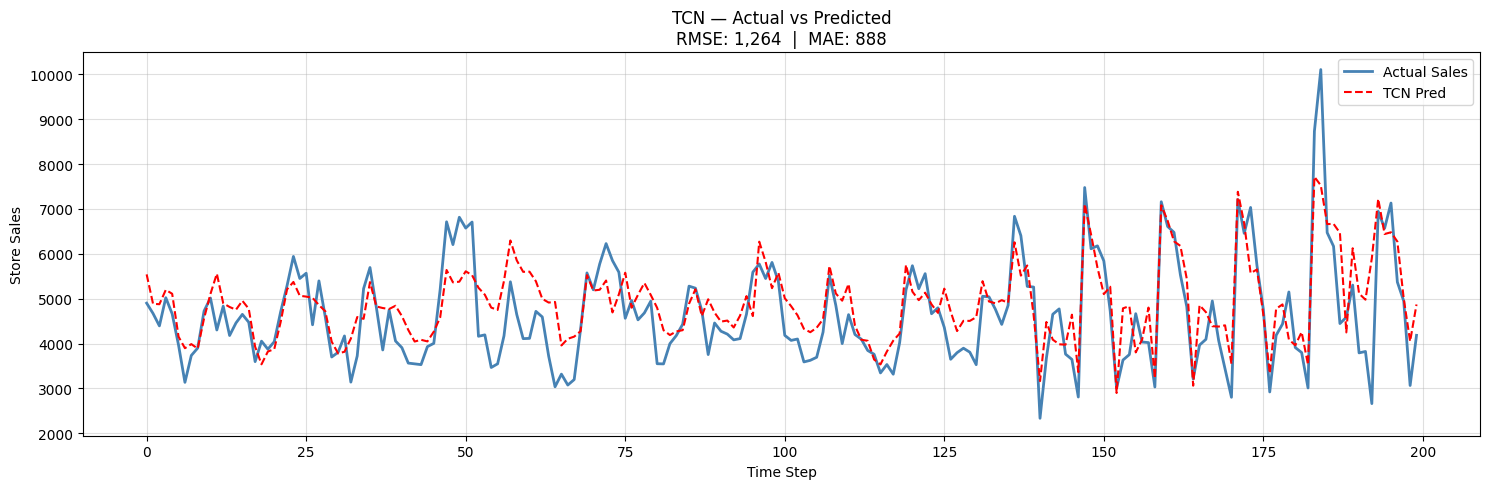

In [ ]:
y_pred_tcn_scaled = model_tcn.predict(X_test)
y_pred_tcn, rmse_tcn, mae_tcn, mape_tcn, r2_tcn = evaluate_model(
    'TCN', y_test_raw, y_pred_tcn_scaled, target_scaler)
results['TCN'] = {'y_pred': y_pred_tcn, 'rmse': rmse_tcn, 'mae': mae_tcn, 'mape': mape_tcn, 'r2': r2_tcn}
plot_predictions(y_test_raw, y_pred_tcn, 'TCN', 'red', rmse_tcn, mae_tcn)

In [ ]:
# Save TCN point model
model_tcn.save(os.path.join(SAVE_PATH, "tcn_model.keras"))
model_tcn.save(os.path.join(SAVE_PATH, "tcn_model.h5"))
with open(os.path.join(SAVE_PATH, "tcn_model.pkl"), "wb") as f:
    pickle.dump(model_tcn, f)

print("✅ TCN model saved in .keras, .h5, and .pkl formats.")

✅ TCN model saved in .keras, .h5, and .pkl formats.


## 🟤 MODEL 7 — N-HiTS

> N-HiTS (Neural Hierarchical Interpolation for Time-Series) stacks multiple
> blocks with different temporal pooling rates. Each block removes its
> backcast from the residual signal before passing it to the next block,
> decomposing the series into trend, seasonality, and noise components.
>
> Three stacks with `pool_sizes=[2, 4, 8]` capture short-term,
> medium-term, and long-term patterns independently.

In [ ]:
class NHiTSBlock(layers.Layer):
    """N-HiTS block: MaxPool → MLP → (backcast, forecast)."""
    def __init__(self, input_size, forecast_size, pool_size,
                 n_layers=2, units=128, **kw):
        super().__init__(**kw)
        self.pool = MaxPooling1D(pool_size=pool_size, strides=1, padding='same')
        mlp_layers = []
        for _ in range(n_layers):
            mlp_layers += [Dense(units, activation='relu'),
                           BatchNormalization(),
                           Dropout(0.1)]
        self.mlp        = keras.Sequential(mlp_layers)
        self.backcast_l = Dense(input_size)
        self.forecast_l = Dense(forecast_size)

    def call(self, x, training=False):
        pooled   = self.pool(x)
        flat     = Flatten()(pooled)
        h        = self.mlp(flat, training=training)
        backcast = self.backcast_l(h)
        forecast = self.forecast_l(h)
        return backcast, forecast


tf.random.set_seed(SEED); np.random.seed(SEED)

INPUT_SIZE = X_train.shape[1]
FEAT_DIM   = X_train.shape[2]
POOL_SIZES = [2, 4]   # 3 stacks ✅

inp      = Input(shape=(INPUT_SIZE, FEAT_DIM))
residual = Flatten()(inp)
forecasts = []

for ps in POOL_SIZES:
    reshaped = layers.Reshape((INPUT_SIZE, FEAT_DIM))(
                   layers.Dense(INPUT_SIZE * FEAT_DIM)(residual)
               )
    block    = NHiTSBlock(INPUT_SIZE * FEAT_DIM, 32,
                          pool_size=ps, units=64)
    bc, fc   = block(reshaped)
    residual = layers.Subtract()([residual, bc])
    forecasts.append(fc)

combined = layers.Add()(forecasts)
x        = Dense(32, activation='relu')(combined)
x        = Dropout(0.2)(x)
out      = Dense(1, activation='sigmoid')(x)

model_nhits = Model(inputs=inp, outputs=out, name='NHiTS_Model')
model_nhits.compile(optimizer=Adam(1e-3), loss='huber', metrics=['mae'])
model_nhits.summary()


Model: "NHiTS_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 60, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 1920)      │          0 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 1920)      │  3,688,320 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 60, 32)    │          0 │ dense_21[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block       │ [(None, 1920),    │    254,496 │ reshape[0][0]     │
│ (NHiTSBlock)        │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 1920)      │          0 │ flatten[0][0],    │
│                     │                   │            │ n_hi_ts_block[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 1920)      │  3,688,320 │ subtract[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_1 (Reshape) │ (None, 60, 32)    │          0 │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_1     │ [(None, 1920),    │    254,496 │ reshape_1[0][0]   │
│ (NHiTSBlock)        │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32)        │          0 │ n_hi_ts_block[0]… │
│                     │                   │            │ n_hi_ts_block_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 32)        │      1,056 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 32)        │          0 │ dense_31[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 1)         │         33 │ dropout_31[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,886,721 (30.09 MB)

 Trainable params: 7,886,209 (30.08 MB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 696s 38ms/step - loss: 9.3948e-04 - mae: 0.0301 - val_loss: 8.0931e-04 - val_mae: 0.0302 - learning_rate: 0.0010
Epoch 2/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 779s 43ms/step - loss: 4.8090e-04 - mae: 0.0222 - val_loss: 9.8721e-04 - val_mae: 0.0317 - learning_rate: 0.0010
Epoch 3/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 800s 44ms/step - loss: 4.1428e-04 - mae: 0.0206 - val_loss: 6.7093e-04 - val_mae: 0.0247 - learning_rate: 0.0010
Epoch 4/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 784s 43ms/step - loss: 3.7714e-04 - mae: 0.0196 - val_loss: 7.0296e-04 - val_mae: 0.0260 - learning_rate: 0.0010
Epoch 5/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 760s 42ms/step - loss: 3.5119e-04 - mae: 0.0188 - val_loss: 8.5867e-04 - val_mae: 0.0293 - learning_rate: 0.0010
Epoch 6/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 737s 40ms/step - loss: 3.3729e-04 - mae: 0.0184 - val_loss: 7.9262e-04 - val_mae: 0.0285 - learning_rate: 0.0010
Epoch 7/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 893s 49ms/step

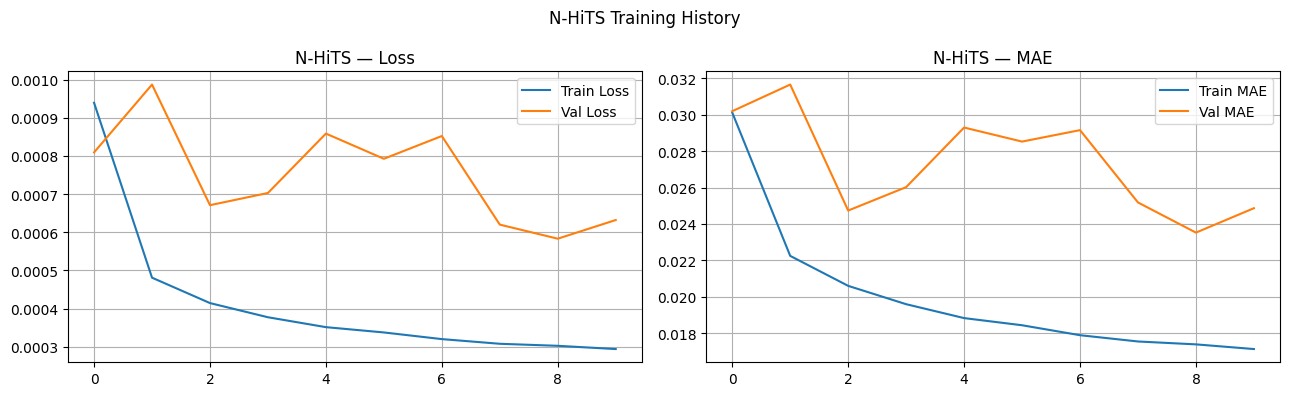

In [ ]:
history_nhits = model_nhits.fit(
    X_train, y_train, epochs=10, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('N-HiTS'), verbose=1
)
plot_history(history_nhits, 'N-HiTS')


In [ ]:
model_nhits.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/nhits_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 44s 10ms/step
N-HiTS                RMSE:     1,418.96  |  MAE:       977.37  |  MAPE: 1710308941.58%  |  R2:     0.79


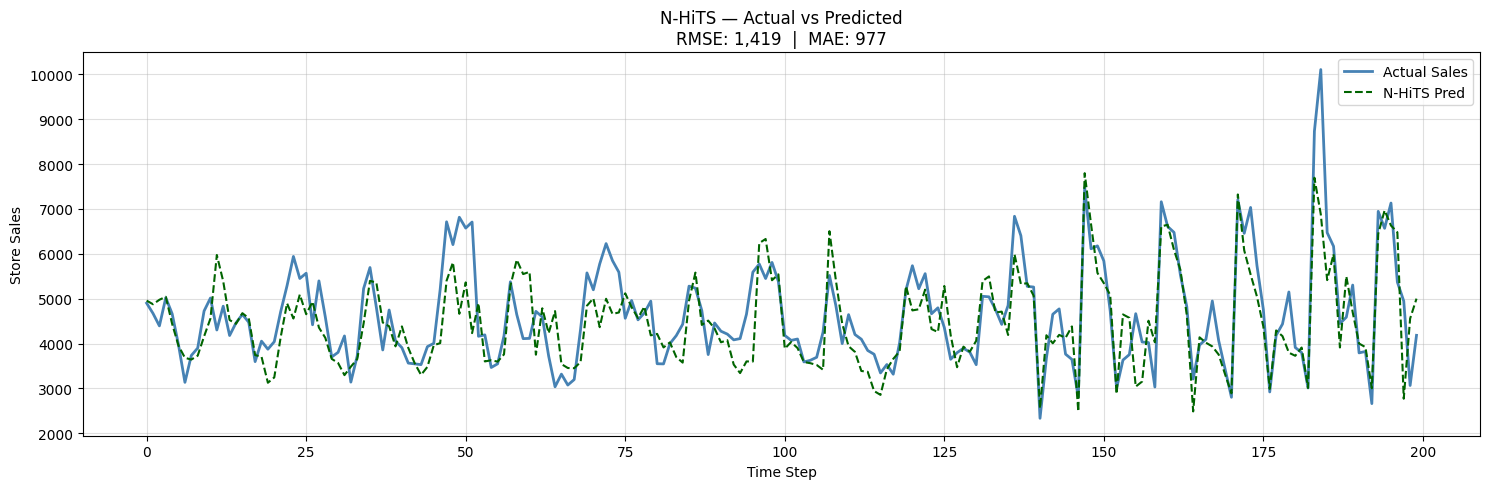

In [ ]:
y_pred_nhits_scaled = model_nhits.predict(X_test)
y_pred_nhits, rmse_nhits, mae_nhits, mape_nhits, r2_nhits = evaluate_model(
    'N-HiTS', y_test_raw, y_pred_nhits_scaled, target_scaler)
results['N-HiTS'] = {'y_pred': y_pred_nhits, 'rmse': rmse_nhits, 'mae': mae_nhits, 'mape': mape_nhits, 'r2': r2_nhits}
plot_predictions(y_test_raw, y_pred_nhits, 'N-HiTS', 'darkgreen', rmse_nhits, mae_nhits)

In [ ]:
# Save N-HiTS point model
model_nhits.save(os.path.join(SAVE_PATH, "nhits_model.keras"))
model_nhits.save(os.path.join(SAVE_PATH, "nhits_model.h5"))
with open(os.path.join(SAVE_PATH, "nhits_model.pkl"), "wb") as f:
    pickle.dump(model_nhits, f)

print("✅ N-HiTS model saved in .keras, .h5, and .pkl formats.")

✅ N-HiTS model saved in .keras, .h5, and .pkl formats.


## 🩵 MODEL 8 — PatchTST

> PatchTST divides the time-series window into overlapping **patches**
> (contiguous sub-sequences) and treats each patch as a token for the
> Transformer. This drastically reduces sequence length (from 60 steps to
> ~10 patch tokens), which lowers attention complexity and forces the model
> to learn patch-level representations rather than point-by-point noise.
>
> `patch_len=12` (2 weeks), `stride=6` (50 % overlap) → rich representations.

In [ ]:
PATCH_LEN    = 12     # ~2 weeks — each patch covers short seasonality cycle
PATCH_STRIDE = 6      # 50 % overlap for richer token representations
D_MODEL      = 64
N_HEADS      = 4
FF_DIM_P     = 128
N_LAYERS_P   = 2
DROPOUT_P    = 0.1

def make_patches(x, patch_len, stride):
    """(batch, time, feat) → (batch, n_patches, patch_len*feat)."""
    seqs = []
    for start in range(0, x.shape[1] - patch_len + 1, stride):
        seqs.append(x[:, start:start + patch_len, :])
    patches = tf.stack(seqs, axis=1)            # (B, n_patches, patch_len, feat)
    B, N, P, F = (tf.shape(patches)[0],
                  patches.shape[1],
                  patch_len,
                  patches.shape[3])
    return tf.reshape(patches, [-1, N, P * patches.shape[3]])


tf.random.set_seed(SEED); np.random.seed(SEED)

inp     = Input(shape=(X_train.shape[1], X_train.shape[2]))
patches = layers.Lambda(
    lambda x: make_patches(x, PATCH_LEN, PATCH_STRIDE),
    name='patch_tokeniser'
)(inp)
x       = Dense(D_MODEL, name='patch_projection')(patches)

for i in range(N_LAYERS_P):
    attn = MultiHeadAttention(num_heads=N_HEADS,
                               key_dim=D_MODEL // N_HEADS,
                               name=f'mha_{i}')(x, x)
    x    = LayerNormalization(name=f'ln1_{i}')(x + Dropout(DROPOUT_P)(attn))
    ffn  = keras.Sequential([
        Dense(FF_DIM_P, activation='gelu'),
        Dense(D_MODEL)
    ], name=f'ffn_{i}')(x)
    x    = LayerNormalization(name=f'ln2_{i}')(x + Dropout(DROPOUT_P)(ffn))

x   = GlobalAveragePooling1D()(x)
x   = Dense(64, activation='relu')(x)
x   = Dropout(0.2)(x)
out = Dense(1, activation='sigmoid')(x)

model_patchtst = Model(inputs=inp, outputs=out, name='PatchTST')
model_patchtst.compile(optimizer=Adam(5e-4), loss='huber', metrics=['mae'])
model_patchtst.summary()


Model: "PatchTST"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 60, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_tokeniser     │ (None, 9, 384)    │          0 │ input_layer_12[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_projection    │ (None, 9, 64)     │     24,640 │ patch_tokeniser[… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_0               │ (None, 9, 64)     │     16,640 │ patch_projection… │
│ (MultiHeadAttentio… │                   │            │ patch_projection… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_33          │ (None, 9, 64)     │          0 │ mha_0[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 9, 64)     │          0 │ patch_projection… │
│                     │                   │            │ dropout_33[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_0               │ (None, 9, 64)     │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_0 (Sequential)  │ (None, 9, 64)     │     16,576 │ ln1_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_34          │ (None, 9, 64)     │          0 │ ffn_0[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 9, 64)     │          0 │ ln1_0[0][0],      │
│                     │                   │            │ dropout_34[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln2_0               │ (None, 9, 64)     │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_1               │ (None, 9, 64)     │     16,640 │ ln2_0[0][0],      │
│ (MultiHeadAttentio… │                   │            │ ln2_0[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 9, 64)     │          0 │ mha_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 9, 64)     │          0 │ ln2_0[0][0],      │
│                     │                   │            │ dropout_36[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln1_1               │ (None, 9, 64)     │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_1 (Sequential)  │ (None, 9, 64)     │     16,576 │ ln1_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 9, 64)     │          0 │ ffn_1[0][0]       │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 95,809 (374.25 KB)

 Trainable params: 95,809 (374.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 179s 10ms/step - loss: 7.6733e-04 - mae: 0.0283 - val_loss: 8.4836e-04 - val_mae: 0.0316 - learning_rate: 5.0000e-04
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 169s 9ms/step - loss: 3.8996e-04 - mae: 0.0197 - val_loss: 0.0010 - val_mae: 0.0339 - learning_rate: 5.0000e-04
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 3.2605e-04 - mae: 0.0179 - val_loss: 6.8505e-04 - val_mae: 0.0272 - learning_rate: 5.0000e-04
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 2.9267e-04 - mae: 0.0169 - val_loss: 6.5072e-04 - val_mae: 0.0261 - learning_rate: 5.0000e-04
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 2.7441e-04 - mae: 0.0163 - val_loss: 6.9081e-04 - val_mae: 0.0265 - learning_rate: 5.0000e-04
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 2.6214e-04 - mae: 0.0159 - val_loss: 6.4713e-04 - val_mae: 0.0261 - learning_rate: 5.0000e-04
Epoch 7/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━

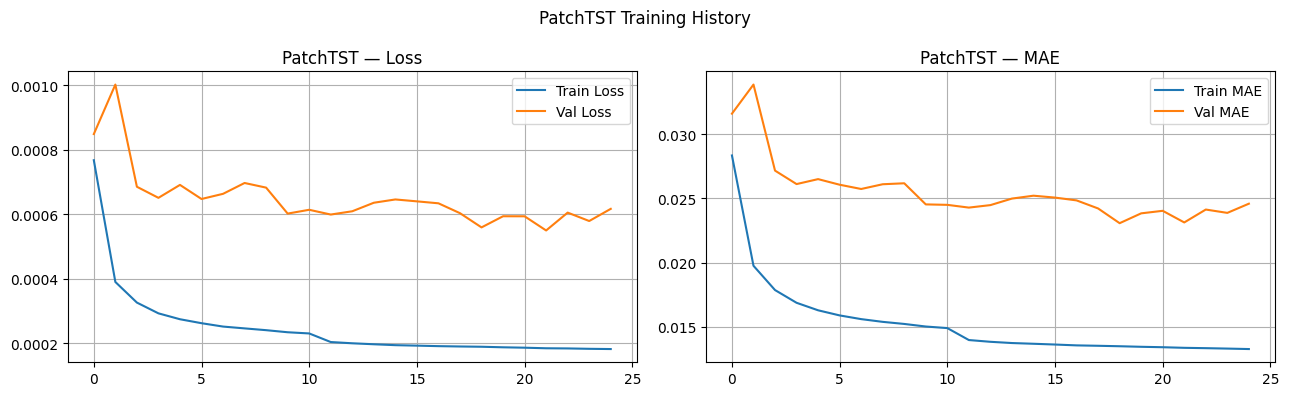

In [ ]:
history_patchtst = model_patchtst.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('PatchTST'), verbose=1
)
plot_history(history_patchtst, 'PatchTST')


In [ ]:
model_patchtst.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/patchtst_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step
PatchTST              RMSE:     1,377.55  |  MAE:       960.68  |  MAPE: 1735894235.48%  |  R2:     0.80


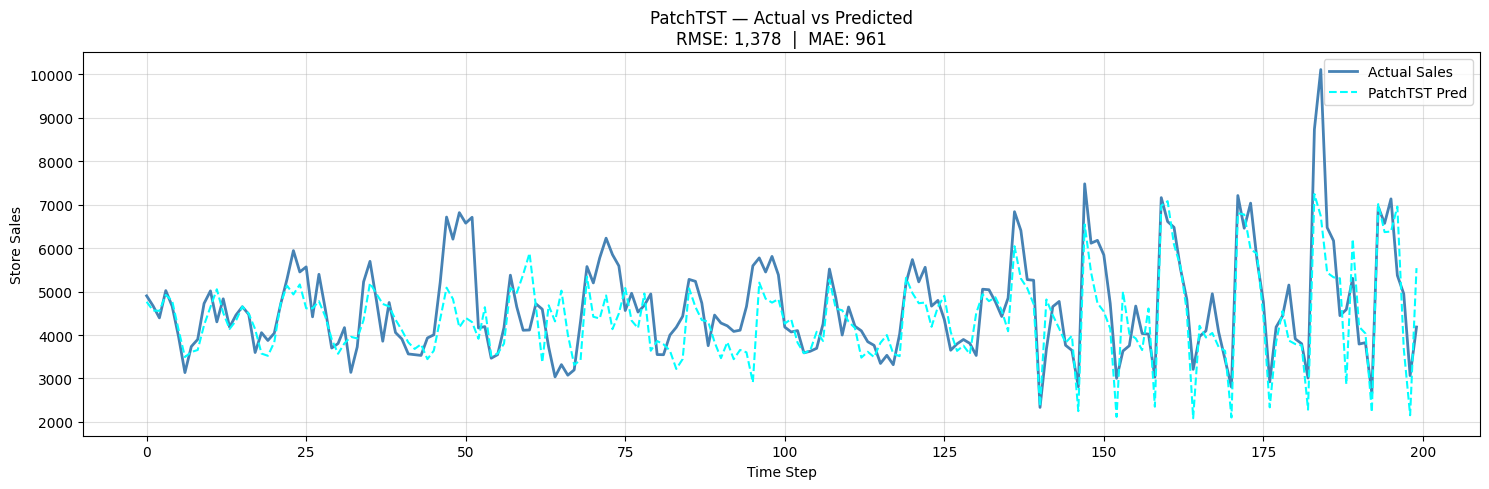

In [ ]:
y_pred_patchtst_scaled = model_patchtst.predict(X_test)
y_pred_patchtst, rmse_patchtst, mae_patchtst, mape_patchtst, r2_patchtst = evaluate_model(
    'PatchTST', y_test_raw, y_pred_patchtst_scaled, target_scaler)
results['PatchTST'] = {'y_pred': y_pred_patchtst, 'rmse': rmse_patchtst, 'mae': mae_patchtst, 'mape': mape_patchtst, 'r2': r2_patchtst}
plot_predictions(y_test_raw, y_pred_patchtst, 'PatchTST', 'cyan', rmse_patchtst, mae_patchtst)

In [ ]:
# Save PatchTST point model
model_patchtst.save(os.path.join(SAVE_PATH, "patchtst_model.keras"))
model_patchtst.save(os.path.join(SAVE_PATH, "patchtst_model.h5"))
with open(os.path.join(SAVE_PATH, "patchtst_model.pkl"), "wb") as f:
    pickle.dump(model_patchtst, f)

print("✅ PatchTST model saved in .keras, .h5, and .pkl formats.")

✅ PatchTST model saved in .keras, .h5, and .pkl formats.


---

# 🔶 PART 2 — Quantile Prediction Models

> Models that output **three quantiles** [0.025, 0.5, 0.975] providing a **95% prediction interval** for each store's daily sales.
>
> **Metrics:** Pinball loss · Coverage rate · Median RMSE / MAE

## 🔧 Quantile Helper Functions

> All shared utilities for quantile training, evaluation, and visualisation are defined
> here **before** any quantile model is built — preventing `NameError` when cells run in order.

In [ ]:
# ── Quantile levels ──────────────────────────────────────────────────────────
quantiles = [0.025, 0.5, 0.975]

# ── Training loss — Pinball / Quantile loss ───────────────────────────────────
def quantile_loss(y_true, y_pred):
    """
    Pinball (quantile) loss over 3 quantiles [0.025, 0.5, 0.975].
    y_pred shape: (batch, 3)   y_true shape: (batch,)
    """
    loss = 0
    for i, q in enumerate(quantiles):
        error = y_true - y_pred[:, i]
        loss += tf.reduce_mean(tf.maximum(q * error, (q - 1) * error))
    return loss / len(quantiles)

# ── Training metric — median branch only ─────────────────────────────────────
def median_mae(y_true, y_pred):
    """
    MAE on the median prediction (index 1) so Keras tracks a meaningful
    scalar metric even though y_pred has 3 columns.
    Using a dedicated function avoids the shape-mismatch error that
    occurs when metrics=['mae'] is passed with a multi-output model.
    """
    return tf.reduce_mean(tf.abs(y_true - y_pred[:, 1]))

# ── Numpy evaluation metric ───────────────────────────────────────────────────
def pinball_loss_np(y_true, y_pred, q):
    """Numpy pinball loss for post-training evaluation."""
    error = y_true - y_pred
    return np.mean(np.maximum(q * error, (q - 1) * error))

# ── History plotting (quantile-aware) ─────────────────────────────────────────
def plot_quantile_history(history, model_name):
    """
    Plot train/val loss and median-MAE for quantile models.
    Uses 'median_mae' key (not 'mae') to match the custom metric name,
    preventing the KeyError: 'mae' that occurs with plot_history().
    """
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(history.history['loss'],          label='Train Loss')
    axes[0].plot(history.history['val_loss'],       label='Val Loss')
    axes[0].set_title(f'{model_name} — Quantile Loss'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['median_mae'],     label='Train Median MAE')
    axes[1].plot(history.history['val_median_mae'], label='Val Median MAE')
    axes[1].set_title(f'{model_name} — Median MAE'); axes[1].legend(); axes[1].grid(True)
    plt.suptitle(f'{model_name} Training History', fontsize=12)
    plt.tight_layout(); plt.show()

# ── Prediction interval plotting ──────────────────────────────────────────────
def plot_quantile_predictions(y_true, q_low, q_med, q_high, model_name,
                               color, rmse, mae, coverage, points=200):
    """Plot actual vs predicted with shaded 95% confidence interval."""
    n = min(points, len(y_true))
    plt.figure(figsize=(15, 5))
    plt.plot(y_true[:n], label='Actual Sales', color='steelblue', lw=2)
    plt.plot(q_med[:n],  label=f'{model_name} Median (RMSE: {rmse:,.0f})',
             color=color, lw=1.5, ls='--')
    plt.fill_between(range(n), q_low[:n], q_high[:n],
                     color=color, alpha=0.2,
                     label=f'95% CI (Coverage: {coverage:.1%})')
    plt.title(f'{model_name} — Actual vs Quantile Predictions\n'
              f'RMSE (Median): {rmse:,.0f}  |  MAE (Median): {mae:,.0f}  |  Coverage: {coverage:.1%}',
              fontsize=12)
    plt.xlabel('Time Step'); plt.ylabel('Store Sales')
    plt.legend(); plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

# ── Quantile evaluate helper ──────────────────────────────────────────────────
def evaluate_quantile_model(name, y_true_raw, y_test_scaled,
                             q_pred_scaled, scaler):
    """
    Inverse-transform the three quantile predictions and compute:
      - Pinball losses per quantile
      - 95% coverage rate
      - RMSE / MAE on the median
    Returns (q_low, q_med, q_high) in original sales units.
    """
    q_low_s  = q_pred_scaled[:, 0]
    q_med_s  = q_pred_scaled[:, 1]
    q_high_s = q_pred_scaled[:, 2]

    q_low  = scaler.inverse_transform(q_low_s.reshape(-1,  1)).flatten()
    q_med  = scaler.inverse_transform(q_med_s.reshape(-1,  1)).flatten()
    q_high = scaler.inverse_transform(q_high_s.reshape(-1, 1)).flatten()

    pb_025 = pinball_loss_np(y_test_scaled, q_low_s,  0.025)
    pb_05  = pinball_loss_np(y_test_scaled, q_med_s,  0.5)
    pb_975 = pinball_loss_np(y_test_scaled, q_high_s, 0.975)
    avg_pb = (pb_025 + pb_05 + pb_975) / 3

    coverage = np.mean((y_true_raw >= q_low) & (y_true_raw <= q_high))
    rmse     = np.sqrt(mean_squared_error(y_true_raw, q_med))
    mae      = mean_absolute_error(y_true_raw, q_med)

    print(f"Pinball Loss (q=0.025) {name}: {pb_025:.4f}")
    print(f"Pinball Loss (q=0.5)   {name}: {pb_05:.4f}")
    print(f"Pinball Loss (q=0.975) {name}: {pb_975:.4f}")
    print(f"Average Pinball Loss   {name}: {avg_pb:.4f}")
    print(f"95% Interval Coverage  {name}: {coverage:.2%}")
    print(f"{name} Quantile (Median) RMSE: {rmse:>12,.2f}  |  MAE: {mae:>12,.2f}")

    return q_low, q_med, q_high, rmse, mae, coverage

quantile_results = {}   # {model_name: (q_med, rmse, mae, coverage)}
print("✅ All quantile helper functions defined.")

✅ All quantile helper functions defined.


---
## 🟨 QUANTILE MODEL 1 — FNN (95% Prediction Interval)

> Same architecture as Point FNN but the **output layer produces 3 quantiles** [0.025, 0.5, 0.975]
> and is trained with **quantile / pinball loss** instead of Huber loss.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

X_train_flat_q = X_train.reshape(X_train.shape[0], -1)
X_test_flat_q  = X_test.reshape(X_test.shape[0], -1)

print(f'Flattened X_train_q shape: {X_train_flat_q.shape}')
print(f'Flattened X_test_q shape:  {X_test_flat_q.shape}')

model_fnn_q = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_flat_q.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(3, activation='sigmoid')   # 3 quantiles, all in [0, 1]
], name='FNN_Quantile_Model')
model_fnn_q.summary()

Flattened X_train_q shape: (584923, 1920)
Flattened X_test_q shape:  (146814, 1920)


Model: "FNN_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_51 (Dense)                │ (None, 128)            │       245,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 256,323 (1001.26 KB)

 Trainable params: 256,323 (1001.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 41s 2ms/step - loss: 0.0059 - median_mae: 0.0261 - val_loss: 0.0085 - val_median_mae: 0.0357 - learning_rate: 0.0010
Epoch 2/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0050 - median_mae: 0.0220 - val_loss: 0.0072 - val_median_mae: 0.0319 - learning_rate: 0.0010
Epoch 3/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0047 - median_mae: 0.0207 - val_loss: 0.0088 - val_median_mae: 0.0378 - learning_rate: 0.0010
Epoch 4/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0045 - median_mae: 0.0201 - val_loss: 0.0094 - val_median_mae: 0.0410 - learning_rate: 0.0010
Epoch 5/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0044 - median_mae: 0.0195 - val_loss: 0.0110 - val_median_mae: 0.0437 - learning_rate: 0.0010
Epoch 6/150
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 38s 2ms/step - loss: 0.0044 - median_mae: 0.0193 - val_loss: 0.0108 - val_median_mae: 0.0421 - learning_rate: 0.0010
Epoch 7/150
18279/18279 ━━━━

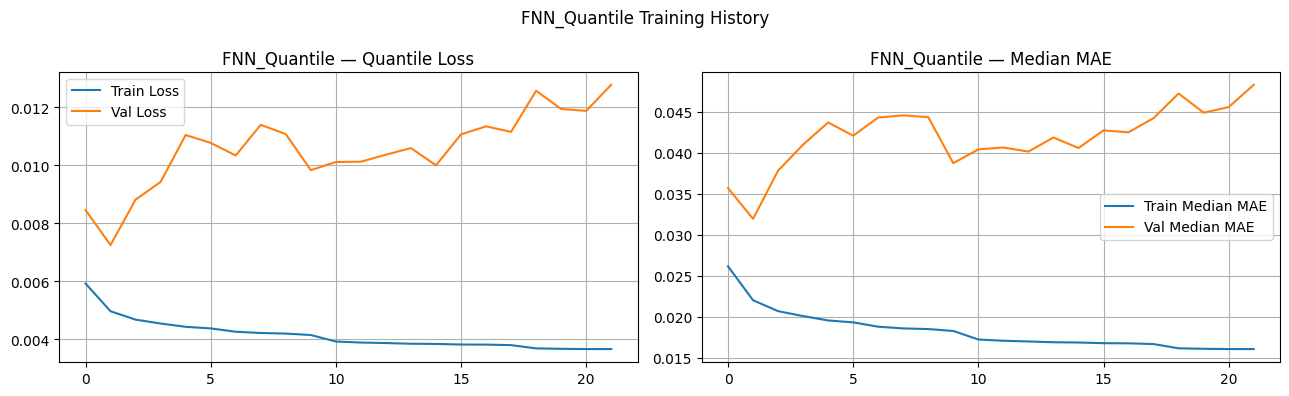

In [ ]:
# Use median_mae metric (defined in quantile helpers) to avoid shape-mismatch
model_fnn_q.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_fnn_q = model_fnn_q.fit(
    X_train_flat_q, y_train, epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
    validation_data=(X_test_flat_q, y_test),
    callbacks=make_callbacks('FNN_Quantile'), verbose=1
)
plot_quantile_history(history_fnn_q, 'FNN_Quantile')

In [ ]:
model_fnn_q.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/fnn_quantile_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 3s 659us/step
Pinball Loss (q=0.025) FNN: 0.0033
Pinball Loss (q=0.5)   FNN: 0.0160
Pinball Loss (q=0.975) FNN: 0.0025
Average Pinball Loss   FNN: 0.0072
95% Interval Coverage  FNN: 78.91%
FNN Quantile (Median) RMSE:     1,672.31  |  MAE:     1,327.12


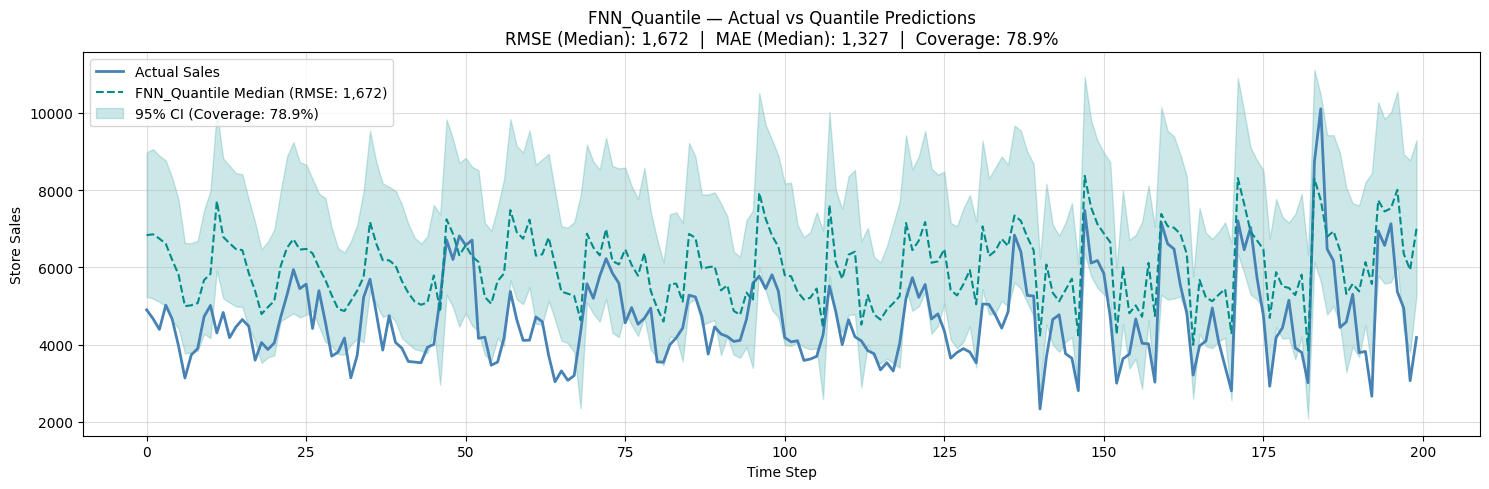

In [ ]:
y_pred_fnn_q_scaled = model_fnn_q.predict(X_test_flat_q)

q_low_fnn, q_med_fnn, q_high_fnn, rmse_fnn_q, mae_fnn_q, coverage_fnn = evaluate_quantile_model(
    'FNN', y_test_raw, y_test, y_pred_fnn_q_scaled, target_scaler
)

quantile_results['FNN_Quantile'] = (q_med_fnn, rmse_fnn_q, mae_fnn_q, coverage_fnn)
plot_quantile_predictions(y_test_raw, q_low_fnn, q_med_fnn, q_high_fnn,
                          'FNN_Quantile', 'darkcyan', rmse_fnn_q, mae_fnn_q, coverage_fnn)

In [ ]:
# Save FNN Quantile model in .keras format
model_fnn_q.save(os.path.join(SAVE_PATH, "fnn_quantile_model.keras"))

# Save FNN Quantile model in .h5 format (legacy Keras format)
model_fnn_q.save(os.path.join(SAVE_PATH, "fnn_quantile_model.h5"))

# Save FNN Quantile model using pickle (less recommended for Keras models)
with open(os.path.join(SAVE_PATH, "fnn_quantile_model.pkl"), "wb") as f:
    pickle.dump(model_fnn_q, f)

print("✅ FNN Quantile model saved in .keras, .h5, and .pkl formats.")

✅ FNN Quantile model saved in .keras, .h5, and .pkl formats.


---
## 🔵 QUANTILE MODEL 2 — SimpleRNN (95% Prediction Interval)

> Stacked 128→64 SimpleRNN, BatchNorm, quantile loss, **3-output sigmoid head**.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_rnn_q = Sequential([
    SimpleRNN(64, return_sequences=True, kernel_regularizer=l2(1e-4),
              input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='sigmoid')   # 3 quantiles
], name='SimpleRNN_Quantile_Model')
model_rnn_q.summary()

Model: "SimpleRNN_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 60, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_55 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_56 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,275 (40.14 KB)

 Trainable params: 10,083 (39.39 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 170s 9ms/step - loss: 0.0083 - median_mae: 0.0318 - val_loss: 0.0085 - val_median_mae: 0.0361 - learning_rate: 0.0010
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0061 - median_mae: 0.0262 - val_loss: 0.0068 - val_median_mae: 0.0287 - learning_rate: 0.0010
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0057 - median_mae: 0.0245 - val_loss: 0.0121 - val_median_mae: 0.0476 - learning_rate: 0.0010
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0056 - median_mae: 0.0240 - val_loss: 0.0059 - val_median_mae: 0.0253 - learning_rate: 0.0010
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0055 - median_mae: 0.0238 - val_loss: 0.0119 - val_median_mae: 0.0473 - learning_rate: 0.0010
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 166s 9ms/step - loss: 0.0055 - median_mae: 0.0235 - val_loss: 0.0828 - val_median_mae: 0.3925 - learning_rate: 0.0010
Epoch 7/25
18279/18279 ━━━━━

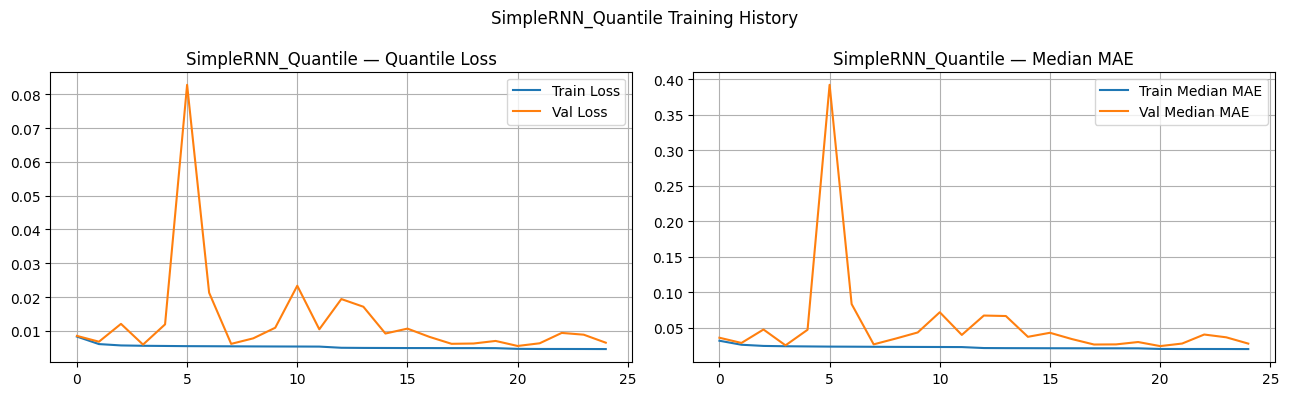

In [ ]:
model_rnn_q.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_rnn_q = model_rnn_q.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('RNN_Quantile'), verbose=1
)
plot_quantile_history(history_rnn_q, 'SimpleRNN_Quantile')

In [ ]:
model_rnn_q.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/simplernn_quantile_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step
Pinball Loss (q=0.025) SimpleRNN: 0.0019
Pinball Loss (q=0.5)   SimpleRNN: 0.0121
Pinball Loss (q=0.975) SimpleRNN: 0.0022
Average Pinball Loss   SimpleRNN: 0.0054
95% Interval Coverage  SimpleRNN: 90.65%
SimpleRNN Quantile (Median) RMSE:     1,359.48  |  MAE:     1,007.66


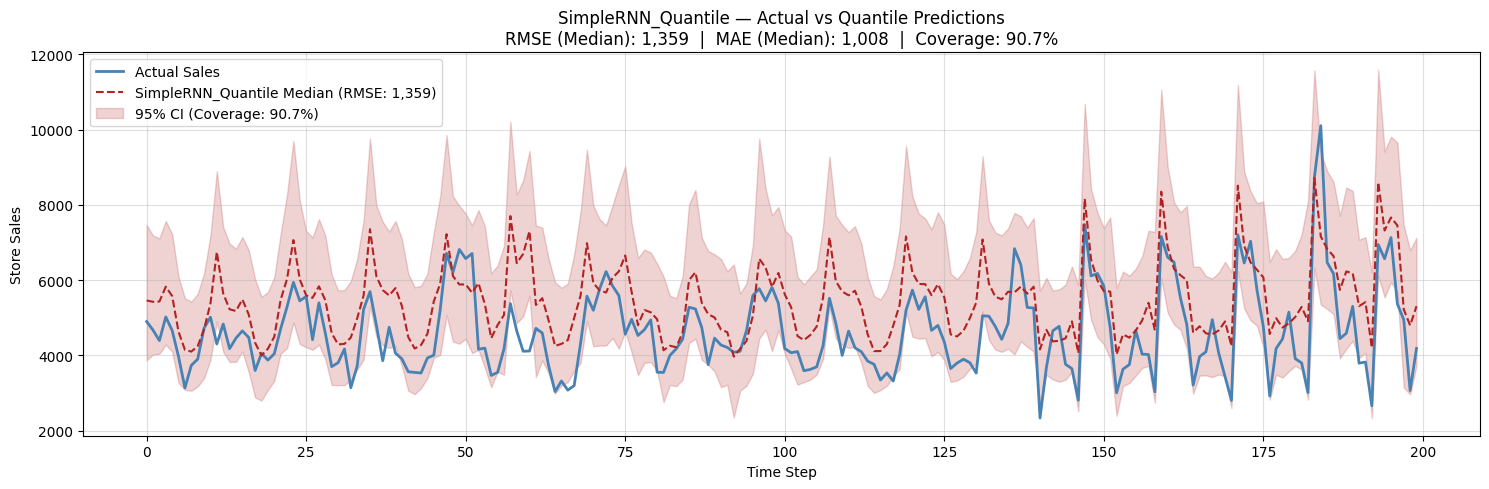

In [ ]:
y_pred_rnn_q_scaled = model_rnn_q.predict(X_test)

q_low_rnn, q_med_rnn, q_high_rnn, rmse_rnn_q, mae_rnn_q, coverage_rnn = evaluate_quantile_model(
    'SimpleRNN', y_test_raw, y_test, y_pred_rnn_q_scaled, target_scaler
)

quantile_results['SimpleRNN_Quantile'] = (q_med_rnn, rmse_rnn_q, mae_rnn_q, coverage_rnn)
plot_quantile_predictions(y_test_raw, q_low_rnn, q_med_rnn, q_high_rnn,
                          'SimpleRNN_Quantile', 'firebrick', rmse_rnn_q, mae_rnn_q, coverage_rnn)

In [ ]:
# Save SimpleRNN Quantile model in .keras format
model_rnn_q.save(os.path.join(SAVE_PATH, "simplernn_quantile_model.keras"))

# Save SimpleRNN Quantile model in .h5 format (legacy Keras format)
model_rnn_q.save(os.path.join(SAVE_PATH, "simplernn_quantile_model.h5"))

# Save SimpleRNN Quantile model using pickle (less recommended for Keras models)
with open(os.path.join(SAVE_PATH, "simplernn_quantile_model.pkl"), "wb") as f:
    pickle.dump(model_rnn_q, f)

print("✅ SimpleRNN Quantile model saved in .keras, .h5, and .pkl formats.")

✅ SimpleRNN Quantile model saved in .keras, .h5, and .pkl formats.


---
## 🟠 QUANTILE MODEL 3 — GRU (95% Prediction Interval)

> 128→64 GRU units, BatchNorm, L2 regularisation, quantile pinball loss.

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

model_gru_q = Sequential([
    GRU(64, return_sequences=True, kernel_regularizer=l2(1e-4),
        input_shape=(X_train.shape[1], X_train.shape[2])),
    BatchNormalization(),
    Dropout(0.2),
    GRU(32, return_sequences=False, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(3, activation='sigmoid')   # 3 quantiles
], name='GRU_Quantile_Model')
model_gru_q.summary()

Model: "GRU_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 60, 64)         │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_57 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_58 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,187 (114.01 KB)

 Trainable params: 28,995 (113.26 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 622s 34ms/step - loss: 0.0077 - median_mae: 0.0296 - val_loss: 0.0056 - val_median_mae: 0.0235 - learning_rate: 0.0010
Epoch 2/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 618s 34ms/step - loss: 0.0053 - median_mae: 0.0223 - val_loss: 0.0061 - val_median_mae: 0.0256 - learning_rate: 0.0010
Epoch 3/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 618s 34ms/step - loss: 0.0049 - median_mae: 0.0205 - val_loss: 0.0056 - val_median_mae: 0.0235 - learning_rate: 0.0010
Epoch 4/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 618s 34ms/step - loss: 0.0046 - median_mae: 0.0194 - val_loss: 0.0060 - val_median_mae: 0.0244 - learning_rate: 0.0010
Epoch 5/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 617s 34ms/step - loss: 0.0045 - median_mae: 0.0188 - val_loss: 0.0057 - val_median_mae: 0.0232 - learning_rate: 0.0010
Epoch 6/25
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 461s 25ms/step - loss: 0.0044 - median_mae: 0.0184 - val_loss: 0.0060 - val_median_mae: 0.0246 - learning_rate: 0.0010
Epoch 7/25
18279/18279

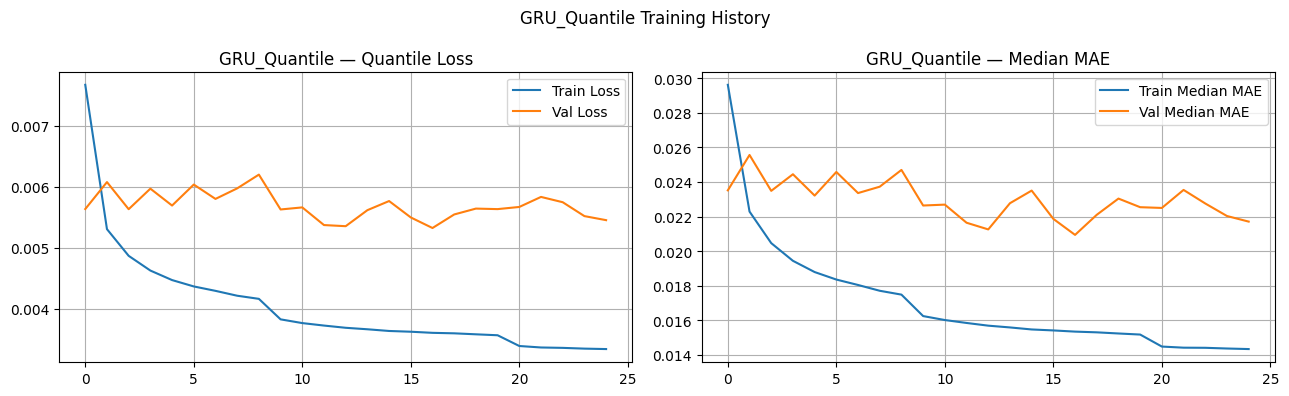

In [ ]:
model_gru_q.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_gru_q = model_gru_q.fit(
    X_train, y_train, epochs=25, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('GRU_Quantile'), verbose=1
)
plot_quantile_history(history_gru_q, 'GRU_Quantile')

In [ ]:
model_gru_q.load_weights("/content/drive/MyDrive/TimeSeriesModels/each_store/gru_quantile_model.keras")

4588/4588 ━━━━━━━━━━━━━━━━━━━━ 29s 6ms/step
Pinball Loss (q=0.025) GRU: 0.0024
Pinball Loss (q=0.5)   GRU: 0.0105
Pinball Loss (q=0.975) GRU: 0.0027
Average Pinball Loss   GRU: 0.0052
95% Interval Coverage  GRU: 84.61%
GRU Quantile (Median) RMSE:     1,291.51  |  MAE:       870.10


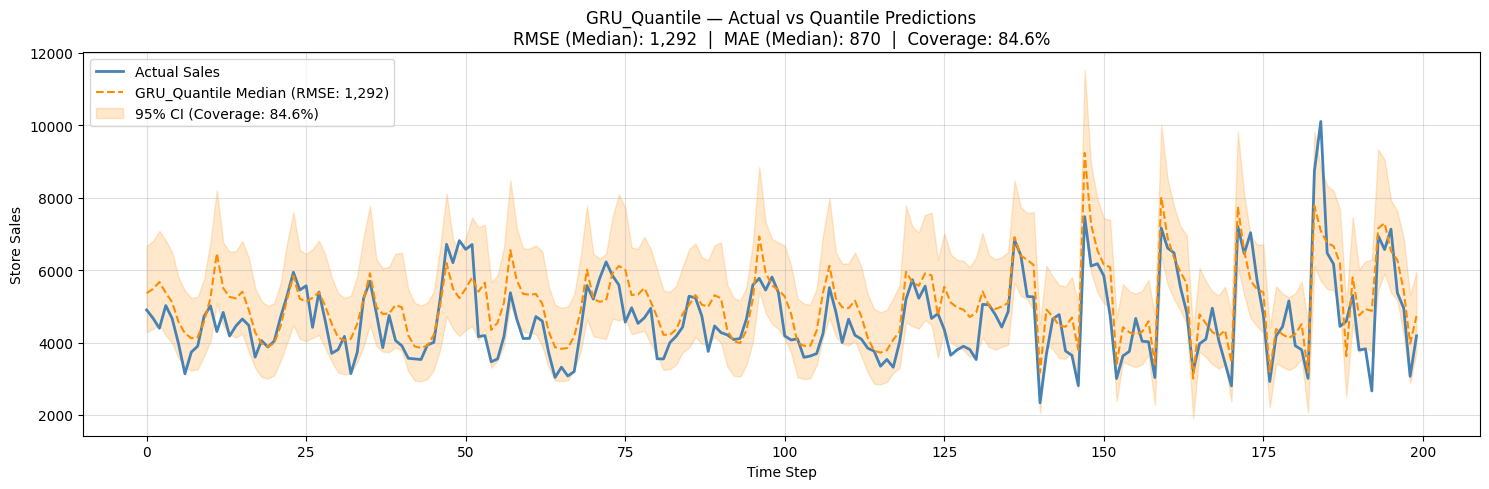

In [ ]:
y_pred_gru_q_scaled = model_gru_q.predict(X_test)

q_low_gru, q_med_gru, q_high_gru, rmse_gru_q, mae_gru_q, coverage_gru = evaluate_quantile_model(
    'GRU', y_test_raw, y_test, y_pred_gru_q_scaled, target_scaler
)

quantile_results['GRU_Quantile'] = (q_med_gru, rmse_gru_q, mae_gru_q, coverage_gru)
plot_quantile_predictions(y_test_raw, q_low_gru, q_med_gru, q_high_gru,
                          'GRU_Quantile', 'darkorange', rmse_gru_q, mae_gru_q, coverage_gru)

In [ ]:
# Save GRU Quantile model in .keras format
model_gru_q.save(os.path.join(SAVE_PATH, "gru_quantile_model.keras"))

# Save GRU Quantile model in .h5 format (legacy Keras format)
model_gru_q.save(os.path.join(SAVE_PATH, "gru_quantile_model.h5"))

# Save GRU Quantile model using pickle (less recommended for Keras models)
with open(os.path.join(SAVE_PATH, "gru_quantile_model.pkl"), "wb") as f:
    pickle.dump(model_gru_q, f)

print("✅ GRU Quantile model saved in .keras, .h5, and .pkl formats.")

✅ GRU Quantile model saved in .keras, .h5, and .pkl formats.


---
## 🟤 QUANTILE MODEL 4 — N-HiTS (95% Prediction Interval)

> Re-uses `NHiTSBlock` from Part 1 (MODEL 7). Hierarchical multi-scale blocks
> decompose the series before producing **3 quantiles** from the combined forecast.

In [ ]:
class NHiTSBlock(layers.Layer):
    """N-HiTS block: MaxPool → MLP → (backcast, forecast)."""
    def __init__(self, input_size, forecast_size, pool_size,
                 n_layers=2, units=128, **kw):
        super().__init__(**kw)
        self.pool = MaxPooling1D(pool_size=pool_size, strides=1, padding='same')
        mlp_layers = []
        for _ in range(n_layers):
            mlp_layers += [Dense(units, activation='relu'),
                           BatchNormalization(),
                           Dropout(0.1)]
        self.mlp        = keras.Sequential(mlp_layers)
        self.backcast_l = Dense(input_size)
        self.forecast_l = Dense(forecast_size)

    def call(self, x, training=False):
        pooled   = self.pool(x)
        flat     = Flatten()(pooled)
        h        = self.mlp(flat, training=training)
        backcast = self.backcast_l(h)
        forecast = self.forecast_l(h)
        return backcast, forecast

In [ ]:
tf.random.set_seed(SEED); np.random.seed(SEED)

INPUT_SIZE = X_train.shape[1]
FEAT_DIM   = X_train.shape[2]
POOL_SIZES = [2, 4]   # 3 stacks: short / medium / long-term

inp      = Input(shape=(INPUT_SIZE, FEAT_DIM))
residual = Flatten()(inp)
forecasts = []

for ps in POOL_SIZES:
    reshaped = layers.Reshape((INPUT_SIZE, FEAT_DIM))(
                   layers.Dense(INPUT_SIZE * FEAT_DIM)(residual)
               )
    block    = NHiTSBlock(INPUT_SIZE * FEAT_DIM, 32,pool_size=ps, units=64)
    bc, fc   = block(reshaped)
    residual = layers.Subtract()([residual, bc])
    forecasts.append(fc)

combined = layers.Add()(forecasts)
x        = Dense(32, activation='relu')(combined)
x        = Dropout(0.2)(x)
out      = Dense(3, activation='sigmoid')(x)   # 3 quantiles

model_nhits_q = Model(inputs=inp, outputs=out, name='NHiTS_Quantile_Model')
model_nhits_q.summary()

Model: "NHiTS_Quantile_Model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 60, 32)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 1920)      │          0 │ input_layer_15[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_39 (Dense)    │ (None, 1920)      │  3,688,320 │ flatten_9[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 60, 32)    │          0 │ dense_39[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_2     │ [(None, 1920),    │    254,496 │ reshape_2[0][0]   │
│ (NHiTSBlock)        │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract_2          │ (None, 1920)      │          0 │ flatten_9[0][0],  │
│ (Subtract)          │                   │            │ n_hi_ts_block_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_44 (Dense)    │ (None, 1920)      │  3,688,320 │ subtract_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 60, 32)    │          0 │ dense_44[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ n_hi_ts_block_3     │ [(None, 1920),    │    254,496 │ reshape_3[0][0]   │
│ (NHiTSBlock)        │ (None, 32)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 32)        │          0 │ n_hi_ts_block_2[… │
│                     │                   │            │ n_hi_ts_block_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_49 (Dense)    │ (None, 32)        │      1,056 │ add_5[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 32)        │          0 │ dense_49[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_50 (Dense)    │ (None, 3)         │         99 │ dropout_43[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,886,787 (30.09 MB)

 Trainable params: 7,886,275 (30.08 MB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
model_nhits_q.compile(optimizer=Adam(1e-3), loss=quantile_loss, metrics=[median_mae])

history_nhits_q = model_nhits_q.fit(
    X_train, y_train, epochs=10, batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    callbacks=make_callbacks('NHiTS_Quantile'), verbose=1
)
plot_quantile_history(history_nhits_q, 'N-HiTS_Quantile')

Epoch 1/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 1390s 76ms/step - loss: 0.0062 - median_mae: 0.0277 - val_loss: 0.0071 - val_median_mae: 0.0313 - learning_rate: 0.0010
Epoch 2/10
18279/18279 ━━━━━━━━━━━━━━━━━━━━ 1387s 76ms/step - loss: 0.0049 - median_mae: 0.0218 - val_loss: 0.0058 - val_median_mae: 0.0250 - learning_rate: 0.0010
Epoch 3/10
   40/18279 ━━━━━━━━━━━━━━━━━━━━ 22:25 74ms/step - loss: 0.0044 - median_mae: 0.0196

In [ ]:
y_pred_nhits_q_scaled = model_nhits_q.predict(X_test)

q_low_nhits, q_med_nhits, q_high_nhits, rmse_nhits_q, mae_nhits_q, coverage_nhits = evaluate_quantile_model(
    'N-HiTS', y_test_raw, y_test, y_pred_nhits_q_scaled, target_scaler
)

quantile_results['N-HiTS_Quantile'] = (q_med_nhits, rmse_nhits_q, mae_nhits_q, coverage_nhits)
plot_quantile_predictions(y_test_raw, q_low_nhits, q_med_nhits, q_high_nhits,
                          'N-HiTS_Quantile', 'olivedrab', rmse_nhits_q, mae_nhits_q, coverage_nhits)

In [ ]:
# Save N-HiTS Quantile model in .keras format
model_nhits_q.save(os.path.join(SAVE_PATH, "nhits_quantile_model.keras"))

# Save N-HiTS Quantile model in .h5 format (legacy Keras format)
model_nhits_q.save(os.path.join(SAVE_PATH, "nhits_quantile_model.h5"))

# Save N-HiTS Quantile model using pickle (less recommended for Keras models)
with open(os.path.join(SAVE_PATH, "nhits_quantile_model.pkl"), "wb") as f:
    pickle.dump(model_nhits_q, f)

print("✅ N-HiTS Quantile model saved in .keras, .h5, and .pkl formats.")

✅ N-HiTS Quantile model saved in .keras, .h5, and .pkl formats.


---
## 📊 PART 2 FINAL — Quantile Model Comparison

In [ ]:
q_comparison = pd.DataFrame([
    {'Model': name, 'Median RMSE': rmse, 'Median MAE': mae, 'Coverage': coverage}
    for name, (_, rmse, mae, coverage) in quantile_results.items()
]).sort_values('Median RMSE').reset_index(drop=True)

print('\n📊 Quantile Model Comparison — Store-Wise Sales (Median Prediction, lower is better):')
display(q_comparison.style
    .format({'Median RMSE': '{:,.2f}', 'Median MAE': '{:,.2f}', 'Coverage': '{:.2%}'})
    .background_gradient(subset=['Median RMSE', 'Median MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['Coverage'], cmap='RdYlGn'))

In [ ]:
Q_COLORS = {
    'FNN_Quantile':         'darkcyan',
    'SimpleRNN_Quantile':   'firebrick',
    'GRU_Quantile':         'darkorange',
    'N-HiTS_Quantile':      'olivedrab',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Median RMSE
q_comparison.plot.barh(x='Model', y='Median RMSE', ax=axes[0],
                        color=[Q_COLORS.get(m, 'gray') for m in q_comparison['Model']],
                        legend=False)
axes[0].set_title('Median RMSE (lower = better)'); axes[0].set_xlabel('RMSE')
axes[0].invert_yaxis(); axes[0].grid(axis='x', alpha=0.4)

# Median MAE
q_comparison.plot.barh(x='Model', y='Median MAE', ax=axes[1],
                        color=[Q_COLORS.get(m, 'gray') for m in q_comparison['Model']],
                        legend=False)
axes[1].set_title('Median MAE (lower = better)'); axes[1].set_xlabel('MAE')
axes[1].invert_yaxis(); axes[1].grid(axis='x', alpha=0.4)

# Coverage
q_comparison.plot.barh(x='Model', y='Coverage', ax=axes[2],
                        color=[Q_COLORS.get(m, 'gray') for m in q_comparison['Model']],
                        legend=False)
axes[2].set_title('95% CI Coverage (closer to 95% = better)'); axes[2].set_xlabel('Coverage')
axes[2].axvline(0.95, color='black', ls='--', lw=1.2, label='Target 95%')
axes[2].legend(fontsize=9); axes[2].invert_yaxis(); axes[2].grid(axis='x', alpha=0.4)

plt.suptitle('Rossmann Store-Wise Sales — Quantile Model Comparison', fontsize=14)
plt.tight_layout(); plt.show()

best_q = q_comparison.iloc[0]
print(f"\n🏆 Best quantile model: {best_q['Model']}  →  Median RMSE: {best_q['Median RMSE']:,.2f}  |  Median MAE: {best_q['Median MAE']:,.2f}  |  Coverage: {best_q['Coverage']:.2%}")

In [ ]:
# ── All-in-one quantile fan plot (first 200 test points) ─────────────────────
n = min(200, len(y_test_raw))
Q_STYLES = ['-', '--', '-.', ':']

plt.figure(figsize=(18, 8))
plt.plot(y_test_raw[:n], label='Actual Sales', color='steelblue', lw=2.5, zorder=5)

for (name, (q_med, rmse, mae, coverage)), ls in zip(quantile_results.items(), Q_STYLES):
    c = Q_COLORS.get(name, 'gray')
    plt.plot(q_med[:n], label=f'{name} median (RMSE={rmse:,.0f})',
             color=c, lw=1.3, ls=ls)

plt.title('All Quantile Models — Store-Wise Sales: Median Predictions vs Actual (First 200 Test Points)',
          fontsize=13)
plt.xlabel('Time Step'); plt.ylabel('Store Sales')
plt.legend(fontsize=8, loc='upper left', ncol=2)
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 🟦 MODEL 9 — Amazon Chronos (`amazon/chronos-2`)

> Foundation model; no training required. Uses median quantile (0.5) as point forecast.

In [ ]:
import sys
!{sys.executable} -m pip install "chronos-forecasting>=2.0" -q

In [ ]:
import os
from chronos import Chronos2Pipeline

# Use the Store/Date backup saved in Section 12 (before Date was dropped).
# df itself no longer has a 'Date' column at this point.
df_chronos_full = df_store_date_for_chronos.copy()
df_chronos_full['target'] = df['Target'].values
df_chronos_full = df_chronos_full.rename(
    columns={'Store': 'id', 'Date': 'timestamp'}
)

# split_index is the number of training windows (from Section 17).
# y_test_raw starts at y_idx_arr[split_index] in the original df.
# Use that same boundary for the Chronos context/future split.
chronos_train_end_idx = int(y_idx_arr[split_index])

train_df_chronos = df_chronos_full.iloc[:chronos_train_end_idx]
future_df        = df_chronos_full.iloc[chronos_train_end_idx:][['id', 'timestamp']]

print(f"Chronos Train Context shape: {train_df_chronos.shape}  "
      f"Future Prediction shape: {future_df.shape}")

# Load the Chronos pipeline
pipeline = Chronos2Pipeline.from_pretrained(
    'amazon/chronos-t5-small',
    device_map='cuda'
)
print('Chronos2Pipeline loaded ✅')

# Determine prediction length per store for the multi-series prediction
num_stores = df_chronos_full['id'].nunique()
pred_len_per_store = len(future_df) // num_stores

pred_df_chronos = pipeline.predict_df(
    train_df_chronos,
    future_df=future_df,
    prediction_length=pred_len_per_store,
    quantile_levels=[0.5],
    id_column='id', timestamp_column='timestamp', target='target',
)

y_pred_chronos = pred_df_chronos['0.5'].values

# Align lengths if needed
if len(y_pred_chronos) != len(y_test_raw):
    print(f"Warning: Chronos predictions ({len(y_pred_chronos)}) != "
          f"y_test_raw ({len(y_test_raw)}). Truncating to shorter.")
    min_len = min(len(y_pred_chronos), len(y_test_raw))
    y_pred_chronos = y_pred_chronos[:min_len]
    y_test_raw_ch  = y_test_raw[:min_len]
else:
    y_test_raw_ch = y_test_raw

rmse_chronos = np.sqrt(mean_squared_error(y_test_raw_ch, y_pred_chronos))
mae_chronos  = mean_absolute_error(y_test_raw_ch, y_pred_chronos)
mape_chronos = mean_absolute_percentage_error(y_test_raw_ch + 1e-8, y_pred_chronos)
r2_chronos   = r2_score(y_test_raw_ch, y_pred_chronos)
print(f"{'Chronos':20s}  RMSE: {rmse_chronos:>12,.2f}  |  MAE: {mae_chronos:>12,.2f}  "
      f"|  MAPE: {mape_chronos:>8.2%}  |  R2: {r2_chronos:>8.2f}")
results['Chronos'] = {
    'y_pred': y_pred_chronos, 'rmse': rmse_chronos,
    'mae': mae_chronos, 'mape': mape_chronos, 'r2': r2_chronos
}
plot_predictions(y_test_raw_ch, y_pred_chronos, 'Chronos', 'darkviolet',
                 rmse_chronos, mae_chronos)

## 📊 FINAL — Model Comparison & All-in-One Chart

In [ ]:
comparison = pd.DataFrame([
    {'Model': name, 'RMSE': metrics['rmse'], 'MAE': metrics['mae'], 'MAPE': metrics['mape'], 'R2': metrics['r2']}
    for name, metrics in results.items()
]).sort_values('RMSE').reset_index(drop=True)

comparison['RMSE_rank'] = comparison['RMSE'].rank().astype(int)

print('\n📊 Model Comparison — Store-Wise Sales Forecasting (lower is better):')
display(comparison.style
    .format({'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'MAPE': '{:.2%}', 'R2': '{:.2f}'})
    .background_gradient(subset=['RMSE', 'MAE', 'MAPE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'], cmap='RdYlGn'))


📊 Model Comparison — Store-Wise Sales Forecasting (lower is better):


,Model,RMSE,MAE,MAPE,R2,RMSE_rank
0,TCN,"1,264.18",887.64,1483708713.46%,0.83,1
1,SimpleRNN,"1,269.67",909.19,1906759814.16%,0.83,2
2,GRU,"1,323.60",909.86,1788642671.88%,0.82,3
3,BiLSTM,"1,356.22","1,005.82",1759615592.86%,0.81,4
4,PatchTST,"1,377.55",960.68,1735894235.48%,0.80,5
5,LSTM,"1,388.42",993.59,1685874992.74%,0.80,6
6,N-HiTS,"1,418.96",977.37,1710308941.58%,0.79,7
7,Transformer,"1,505.99","1,162.46",1556068226.04%,0.76,8
8,FNN,"2,597.95","2,350.19",1908537242.58%,0.29,9


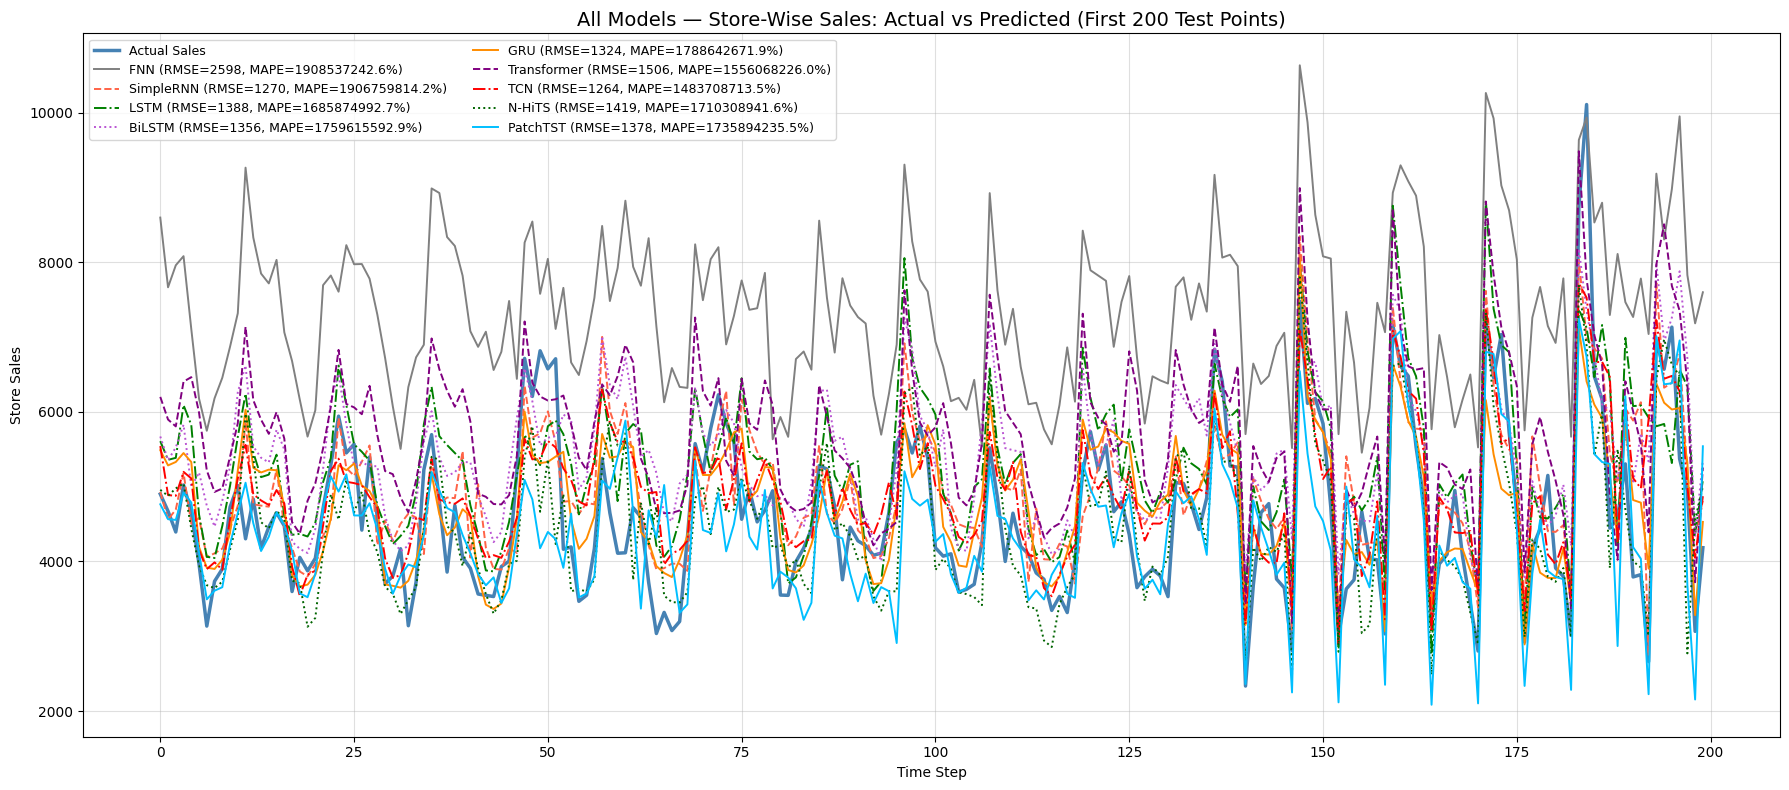

In [ ]:
# ── All-in-one comparison plot ─────────────────────────────────────
COLORS = {
    'FNN': 'gray', 'SimpleRNN': 'tomato', 'LSTM': 'green',    'BiLSTM': 'mediumorchid',
    'GRU': 'darkorange',   'Transformer': 'purple', 'TCN': 'red',
    'N-HiTS': 'darkgreen', 'PatchTST': 'deepskyblue', 'Chronos': 'darkviolet'
}
STYLES = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']

n = min(200, len(y_test_raw))
plt.figure(figsize=(18, 8))
plt.plot(y_test_raw[:n], label='Actual Sales', color='steelblue', lw=2.5)
for (name, metrics), ls in zip(results.items(), STYLES):
    plt.plot(metrics['y_pred'][:n],
             label=f"{name} (RMSE={metrics['rmse']:.0f}, MAPE={metrics['mape']:.1%})",
             color=COLORS.get(name, 'gray'), lw=1.4, ls=ls)

plt.title('All Models — Store-Wise Sales: Actual vs Predicted (First 200 Test Points)',
          fontsize=14)
plt.xlabel('Time Step'); plt.ylabel('Store Sales')
plt.legend(fontsize=9, loc='upper left', ncol=2)
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

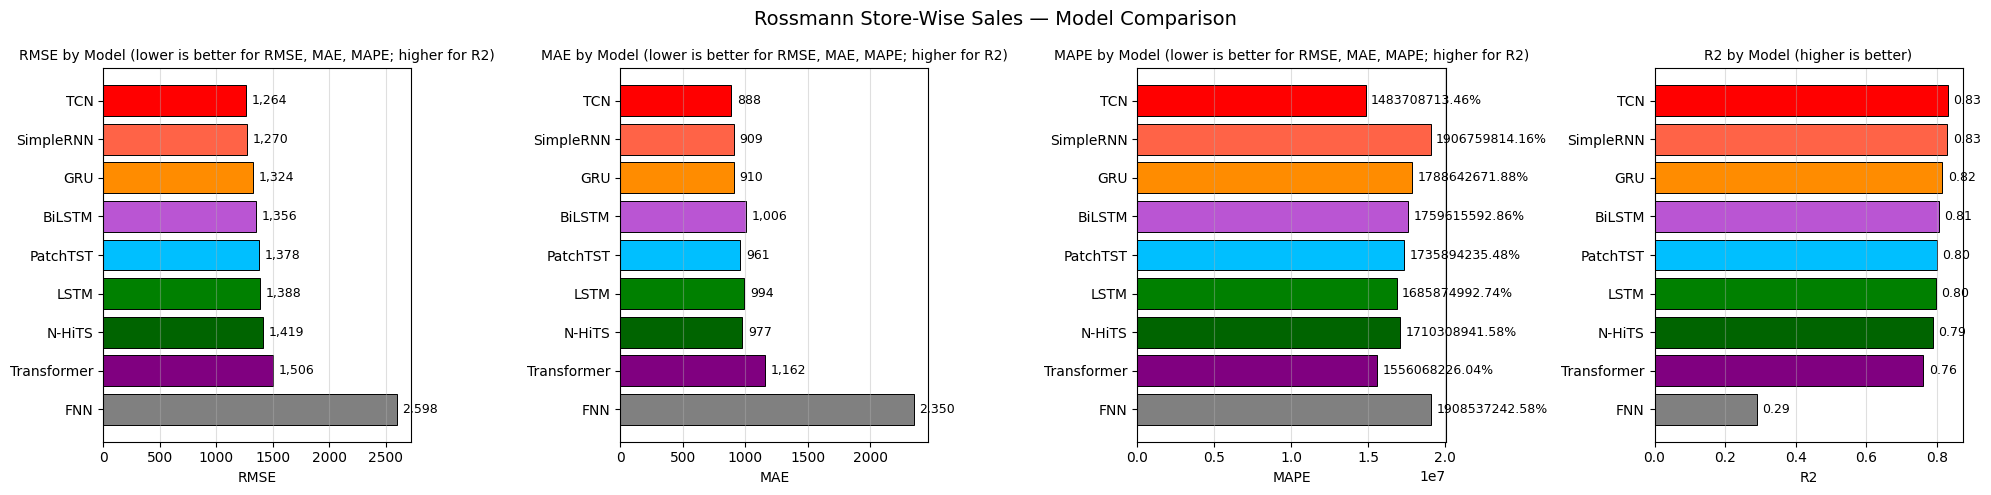


🏆 Best model: TCN  →  RMSE: 1,264.18  |  MAE: 887.64  |  MAPE: 1483708713.46%  |  R2: 0.83


In [ ]:
# ── Bar chart: RMSE / MAE / MAPE / R2 side by side ───────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'R2']
fmts = ['{:,.0f}', '{:,.0f}', '{:.2%}', '{:.2f}']

for i, (ax, metric, fmt) in enumerate(zip(axes, metrics_to_plot, fmts)):
    vals  = comparison[metric].tolist()
    mods  = comparison['Model'].tolist()
    cols  = [COLORS.get(m, 'gray') for m in mods]
    bars  = ax.barh(mods, vals, color=cols, edgecolor='black', linewidth=0.7)
    # Use labels= (list of formatted strings) instead of fmt= to support
    # Python-style format strings like '{:,.0f}' and '{:.2%}'
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals], padding=4, fontsize=9)
    ax.set_title(f'{metric} by Model (lower is better for RMSE, MAE, MAPE; higher for R2)', fontsize=10)
    ax.set_xlabel(metric)
    ax.invert_yaxis()  # Keep best at top
    ax.grid(axis='x', alpha=0.4)
    if metric == 'R2':
        ax.set_title(f'{metric} by Model (higher is better)', fontsize=10)

plt.suptitle('Rossmann Store-Wise Sales — Model Comparison', fontsize=14)
plt.tight_layout(); plt.show()

best = comparison.iloc[0]
print(f"\n🏆 Best model: {best['Model']}  →  RMSE: {best['RMSE']:,.2f}  |  MAE: {best['MAE']:,.2f}  |  MAPE: {best['MAPE']:.2%}  |  R2: {best['R2']:.2f}")
